# Optimización Bajo Incertidumbre (IIND 4125)

## Proyecto 3: Decisiones Secuenciales — MDP, Políticas y Aprendizaje

#### Objetivo: Tomar decisiones adaptativas en el tiempo mientras evolucionan fallas, demanda y generación

## 1. Punto de Partida: Reformulación Secuencial


| Elemento | Símbolo | Definición en el problema de resiliencia eléctrica |
|---|---|---|
| **Estado** | $S_t$ | Estado de la red eléctrica en el periodo $t$: capacidades disponibles de los arcos, arcos reforzados, arcos fallados, generación disponible, demanda nodal, déficit acumulado, presupuesto restante y régimen del sistema (Mediocristan o Extremistan). |
| **Decisión** | $x_t$ | Decisiones operativas y de inversión tomadas en el periodo $t$: reforzar arcos, reparar infraestructura, redistribuir flujo eléctrico y gestionar generación y déficit. |
| **Información exógena** | $W_{t+1}$ | Información incierta observada al pasar al periodo $t+1$: demanda eléctrica, disponibilidad de generación, fallas en líneas, reducción de capacidad, shocks extremos y ocurrencia de crisis sistémicas. |
| **Función de transición** | $S^M$ | Evolución de la red después de aplicar decisiones y observar incertidumbre. Las capacidades, disponibilidad y déficit se actualizan dinámicamente según las acciones tomadas y los shocks del entorno. |
| **Función de costo** | $C_t$ | Costo total del periodo: costos de operación de flujo, penalización por demanda no servida, costos de refuerzo y costos de reparación de infraestructura. |

### Función de transición

$S_{t+1} = S^M(S_t, x_t, W_{t+1})$

Por ejemplo, la capacidad de un arco puede evolucionar como:


$U_{e,t+1}=U_{e,t}$ $+\Delta U_e h_{e,t}-\text{fallas}_{e,t+1}$

donde:

- $h_{e,t}$ indica si el arco es reforzado,
- $\Delta U_e$ representa el incremento de capacidad,
- $\text{fallas}_{e,t+1}$ modela pérdidas de capacidad debidas a eventos extremos.

### Función de costo

$C_t =
\sum_{e \in E} c_e f_{e,t}
+
\pi \sum_{i \in L} \delta_{i,t}
+
\sum_{e \in E} H_e h_{e,t}
+
\sum_{e \in E} R_e r_{e,t}$


donde:

- $f_{e,t}$: flujo enviado por el arco $e$,
- $\delta_{i,t}$: demanda no servida,
- $h_{e,t}$: decisión de refuerzo,
- $r_{e,t}$: decisión de reparación,
- $\pi$: penalización por déficit.

## 2. Ambiente de Simulación



### 2.1 Generador de Variables Aleatorias

Función `generate_W(T, seed, mode)` que produce una secuencia temporal de información exógena para un episodio de $T$ periodos.

- **`mode='mediocristan'`**: ruido moderado, distribuciones clásicas (coherente con Proyecto 1).
- **`mode='extremistan'`**: colas pesadas, cambios de régimen, shocks (coherente con Proyecto 1).
- La semilla (`seed`) debe garantizar reproducibilidad.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import networkx as nx

In [5]:
from scenarios_utils import load_edges_from_csv, load_nodes_from_csv

INSTANCE = 69

edges = load_edges_from_csv("edges.csv")
nodes_all = load_nodes_from_csv("nodes.csv")

nodes = nodes_all[nodes_all["instance"] == INSTANCE].reset_index(drop=True)

print("Instancia:", INSTANCE)
print("Nodos:", len(nodes))
print("Arcos:", len(edges))

Instancia: 69
Nodos: 118
Arcos: 179


In [6]:
INSTANCE = 69


edges = load_edges_from_csv("edges.csv")
nodes = load_nodes_from_csv("nodes.csv")

nodes = nodes[nodes["instance"] == INSTANCE].reset_index(drop=True)

## Generación de Escenarios

En cada periodo $t$, el escenario generado incluye:

- demanda nodal,
- capacidad efectiva de transmisión,
- disponibilidad de generación,
- costos operativos,
- ocurrencia de crisis,
- fallas correlacionadas de infraestructura.

In [7]:
def generate_dynamic_scenarios(
    nodes,
    edges,
    T=10,
    n_paths=100,
    seed=123,
    p_crisis=0.10,
    dem_sigma=0.10,
    cost_sigma=0.05,
    crisis_dem_mult=2.0,
    crisis_cost_mult=2.0,
    p_outage=0.02,
    crisis_p_outage=0.20,
    cap_drop=0.70
):
    """
    Genera trayectorias dinámicas W_1, ..., W_T. Cada T es un periodo
    y cada W_t tiene TODA la información del problema.  
    """

    rng = np.random.default_rng(seed)

    rows_D = []
    rows_U = []
    rows_c = []
    rows_G = []
    rows_info = []

    for path in range(n_paths):

        for t in range(1, T + 1):

            crisis = rng.random() < p_crisis

            # Multiplicadores por régimen
            if crisis:
                dem_mult = rng.lognormal(mean=np.log(crisis_dem_mult), sigma=0.25)
                cost_mult = crisis_cost_mult
                outage_prob = crisis_p_outage
            else:
                dem_mult = max(rng.normal(1.0, dem_sigma), 0.0)
                cost_mult = max(rng.normal(1.0, cost_sigma), 0.1)
                outage_prob = p_outage

            # Demanda y generación
            for _, r in nodes.iterrows():

                node = int(r["node"])
                d_base = float(r.get("d", 0.0))
                g_base = float(r.get("p_max", 0.0)) if bool(r.get("is_generator", False)) else 0.0

                rows_D.append({
                    "path": path,
                    "t": t,
                    "node": node,
                    "D_it": d_base * dem_mult
                })

                rows_G.append({
                    "path": path,
                    "t": t,
                    "node": node,
                    "G_it": g_base * max(rng.normal(1.0, 0.05), 0.0)
                })

            # Capacidad y costos de arcos
            for _, r in edges.iterrows():

                e = int(r["e_id"])
                U_base = float(r.get("U_base", r.get("f_max", 100.0)))
                c_base = float(r.get("c_base", 1.0))

                failed = rng.random() < outage_prob
                U_mult = cap_drop if failed else 1.0

                rows_U.append({
                    "path": path,
                    "t": t,
                    "e_id": e,
                    "U_et": U_base * U_mult,
                    "failed": failed
                })

                rows_c.append({
                    "path": path,
                    "t": t,
                    "e_id": e,
                    "c_et": c_base * cost_mult
                })

            rows_info.append({
                "path": path,
                "t": t,
                "crisis": crisis,
                "dem_mult": dem_mult,
                "cost_mult": cost_mult
            })

    dfD_dyn = pd.DataFrame(rows_D)
    dfU_dyn = pd.DataFrame(rows_U)
    dfc_dyn = pd.DataFrame(rows_c)
    dfG_dyn = pd.DataFrame(rows_G)
    df_info_dyn = pd.DataFrame(rows_info)

    return dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn

In [8]:
dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn = generate_dynamic_scenarios(
    nodes=nodes,
    edges=edges,
    T=12,
    n_paths=10,
    seed=2026,
    p_crisis=0.15
)

df_info_dyn

,path,t,crisis,dem_mult,cost_mult
0,0,1,False,1.024057,0.905184
1,0,2,False,0.907642,1.024866
2,0,3,False,1.022961,1.005959
3,0,4,False,1.126639,1.028948
4,0,5,False,0.929139,0.987031
...,...,...,...,...,...
115,9,8,True,1.942448,2.000000
116,9,9,False,1.135964,0.980327
117,9,10,False,0.935621,1.039128
118,9,11,False,1.045840,0.994056


A diferencia de los proyectos anteriores, donde las decisiones de inversión se tomaban una sola vez sobre un conjunto fijo de escenarios, ahora la red evoluciona dinámicamente a través del tiempo. 

Para ello se definieron explícitamente los cinco elementos fundamentales del modelo: 
- el estado del sistema, 
- las decisiones de control, 
- la información exógena incierta, 
- la función de transición y 
- la función de costo. 

Además, los generadores de incertidumbre previamente desarrollados para Mediocristan y Extremistan fueron extendidos para producir secuencias temporales de shocks, permitiendo modelar eventos extremos, fallas de infraestructura y variaciones de demanda a lo largo de múltiples periodos. Esta reformulación permite estudiar políticas adaptativas y evaluar cómo diferentes estrategias de operación e inversión responden dinámicamente frente a escenarios normales y extremos.


In [9]:
def get_exogenous_info(path, t, dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn):
    """
    Extrae la información exógena W_{t+1} para un path y periodo dado.
    """

    D_t = (
        dfD_dyn[(dfD_dyn["path"] == path) & (dfD_dyn["t"] == t)]
        .set_index("node")["D_it"]
        .to_dict()
    )

    U_t = (
        dfU_dyn[(dfU_dyn["path"] == path) & (dfU_dyn["t"] == t)]
        .set_index("e_id")["U_et"]
        .to_dict()
    )

    failed_t = (
        dfU_dyn[(dfU_dyn["path"] == path) & (dfU_dyn["t"] == t)]
        .set_index("e_id")["failed"]
        .astype(int)
        .to_dict()
    )

    c_t = (
        dfc_dyn[(dfc_dyn["path"] == path) & (dfc_dyn["t"] == t)]
        .set_index("e_id")["c_et"]
        .to_dict()
    )

    G_t = (
        dfG_dyn[(dfG_dyn["path"] == path) & (dfG_dyn["t"] == t)]
        .set_index("node")["G_it"]
        .to_dict()
    )

    info_row = df_info_dyn[
        (df_info_dyn["path"] == path) & (df_info_dyn["t"] == t)
    ].iloc[0]

    W = {
        "D": D_t,
        "U": U_t,
        "failed": failed_t,
        "c": c_t,
        "G": G_t,
        "crisis": bool(info_row["crisis"]),
        "dem_mult": float(info_row["dem_mult"]),
        "cost_mult": float(info_row["cost_mult"])
    }

    return W

### 2.2 Función de Costo

Esta función captura simultáneamente los costos de operación, los costos de reforzamiento y reparación de infraestructura, y las penalizaciones asociadas a demanda no servida.

La contribución del periodo $t$ se modela como:

$C_t(S_t,x_t,W_{t+1})=$
$\underbrace{\sum_{e\in E} c_{e,t} f_{e,t}}_{\text{Costo operativo}}$
$+\underbrace{\pi \sum_{i\in N}\delta_{i,t}}_{\text{Penalización por déficit}}+$
$\underbrace{\sum_{e\in E} H_e r_{e,t}}_{\text{Costo de refuerzo}}+$
$\underbrace{\sum_{e\in E} R_e a_{e,t}}_{\text{Costo de reparación}}$

donde:

- $c_{e,t}$: costo operativo del arco $e$,
- $f_{e,t}$: flujo de energía transportado,
- $\delta_{i,t}$: demanda no servida en el nodo $i$,
- $\pi$: penalización unitaria por déficit,
- $H_e$: costo de reforzar el arco $e$,
- $r_{e,t}\in\{0,1\}$: decisión de reforzamiento,
- $R_e$: costo de reparación,
- $a_{e,t}\in\{0,1\}$: decisión de reparación.

---

### Objetivo dinámico total

El objetivo global del problema consiste en minimizar el costo esperado acumulado a lo largo del horizonte temporal:

$
\min
\mathbb{E}
\left[
\sum_{t=1}^{T} C_t
\right]
$


In [10]:
def compute_period_cost(
    state,
    action,
    W,
    operating_result,
    H_e,
    repair_cost=25.0,
    pi=190.0
):
    """
    Calcula el costo C_t del periodo.
    """

    reinforcement_cost = sum(
        H_e[e] * action["reinforce"].get(e, 0)
        for e in H_e
        if state["reinforced"].get(e, 0) == 0
    )

    repair_cost_total = repair_cost * sum(
        action["repair"].get(e, 0)
        for e in H_e
    )

    operating_cost = operating_result.get("operating_cost", 0.0)

    deficit_cost = pi * operating_result.get("total_deficit", 0.0)

    total_cost = (
        reinforcement_cost
        + repair_cost_total
        + operating_cost
        + deficit_cost
    )

    return {
        "total_cost": total_cost,
        "reinforcement_cost": reinforcement_cost,
        "repair_cost": repair_cost_total,
        "operating_cost": operating_cost,
        "deficit_cost": deficit_cost
    }

In [11]:
def simple_operating_model(state, action, W):

    total_demand = sum(W["D"].values())
    total_generation = sum(W["G"].values())

    served = min(total_demand, total_generation)
    deficit = max(total_demand - total_generation, 0.0)

    operating_cost = 0.0

    return {
        "served_demand": served,
        "total_deficit": deficit,
        "operating_cost": operating_cost
    }

In [12]:
def validate_operational_decisions(state, action, W, nodes, edges):
    """
    Valida y ajusta las decisiones operativas:
    - flujo no negativo
    - flujo <= capacidad
    - generación no negativa
    - generación despachada <= generación disponible
    """

    edges_list = edges["e_id"].astype(int).tolist()
    nodes_list = nodes["node"].astype(int).tolist()

    flow = {}
    generation_dispatch = {}

    for e in edges_list:
        f_e = float(action.get("flow", {}).get(e, 0.0))
        cap_e = max(float(state["capacity"].get(e, 0.0)), 0.0)

        # Si el arco está fallado, su flujo permitido es cero
        if state["failed"].get(e, 0) == 1:
            cap_e = 0.0

        flow[e] = min(max(f_e, 0.0), cap_e)

    for i in nodes_list:
        g_i = float(action.get("generation_dispatch", {}).get(i, 0.0))
        G_i = max(float(W["G"].get(i, 0.0)), 0.0)

        generation_dispatch[i] = min(max(g_i, 0.0), G_i)

    return flow, generation_dispatch

In [13]:
def operating_model_from_action(state, action, W, nodes, edges):
    """
    Evalúa la operación dada por la acción:
    - usa action["flow"] como flujo por arco
    - usa action["generation_dispatch"] como generación despachada

    Calcula déficit por balance nodal.
    """

    nodes_list = nodes["node"].astype(int).tolist()
    edges_list = edges["e_id"].astype(int).tolist()

    in_arcs = {
        int(i): edges.loc[edges["j"] == i, "e_id"].astype(int).tolist()
        for i in nodes_list
    }

    out_arcs = {
        int(i): edges.loc[edges["i"] == i, "e_id"].astype(int).tolist()
        for i in nodes_list
    }

    flow, generation_dispatch = validate_operational_decisions(
        state=state,
        action=action,
        W=W,
        nodes=nodes,
        edges=edges
    )

    delta = {}
    served_by_node = {}

    for i in nodes_list:
        demand_i = max(float(W["D"].get(i, 0.0)), 0.0)

        inflow_i = sum(flow[e] for e in in_arcs.get(i, []))
        outflow_i = sum(flow[e] for e in out_arcs.get(i, []))
        gen_i = generation_dispatch.get(i, 0.0)

        available_i = gen_i + inflow_i - outflow_i

        served_i = min(demand_i, max(available_i, 0.0))
        deficit_i = max(demand_i - served_i, 0.0)

        served_by_node[i] = served_i
        delta[i] = deficit_i

    operating_cost = sum(
        W["c"].get(e, 0.0) * flow[e]
        for e in edges_list
    )

    total_demand = sum(max(float(W["D"].get(i, 0.0)), 0.0) for i in nodes_list)
    total_deficit = sum(delta.values())
    served_demand = total_demand - total_deficit

    return {
        "served_demand": served_demand,
        "total_deficit": total_deficit,
        "operating_cost": operating_cost,
        "flow": flow,
        "generation_dispatch": generation_dispatch,
        "delta": delta,
        "served_by_node": served_by_node
    }

### 2.3 Función de Transición

In [14]:
def initialize_state(nodes, edges, budget=2000.0):
    """
    Crea el estado inicial S_0 de la red.
    """

    state = {
        "t": 0,
        "budget_remaining": float(budget),

        "reinforced": {
            int(e): 0 for e in edges["e_id"]
        },

        "capacity": {
            int(r["e_id"]): float(r.get("U_base", r.get("f_max", 100.0)))
            for _, r in edges.iterrows()
        },

        "failed": {
            int(e): 0 for e in edges["e_id"]
        },

        "flow": {
            int(e): 0.0 for e in edges["e_id"]
        },

        "generation_dispatch": {
            int(r["node"]): 0.0 for _, r in nodes.iterrows()
        },

        "cumulative_deficit": 0.0,
        "cumulative_cost": 0.0,

        "demand": {
            int(r["node"]): float(r.get("d", 0.0))
            for _, r in nodes.iterrows()
        },

        "generation_available": {
            int(r["node"]): float(r.get("p_max", 0.0)) if bool(r.get("is_generator", False)) else 0.0
            for _, r in nodes.iterrows()
        },

        "crisis": False
    }

    return state

In [15]:
def transition(
    state,
    action,
    W,
    nodes,
    edges,
    H_e,
    delta_u=0.8,
    budget_floor=0.0,
    repair_cost=25.0,
    pi=190.0
):
    """
    Transición determinista:
    S_{t+1} = S^M(S_t, x_t, W_{t+1})

    Acción:
    x_t = {
        "reinforce": refuerzo de arcos,
        "repair": reparación de arcos,
        "flow": flujo por arco,
        "generation_dispatch": generación despachada por nodo
    }
    """

    next_state = state.copy()

    next_state["reinforced"] = state["reinforced"].copy()
    next_state["capacity"] = state["capacity"].copy()
    next_state["failed"] = state["failed"].copy()

    next_state["demand"] = W["D"].copy()
    next_state["generation_available"] = W["G"].copy()

    # --------------------------------------------------------
    # 1. Aplicar refuerzo
    # --------------------------------------------------------

    for e, reinforce_decision in action["reinforce"].items():

        if reinforce_decision == 1 and next_state["reinforced"].get(e, 0) == 0:

            cost_e = H_e[e]

            if next_state["budget_remaining"] - cost_e >= budget_floor:

                next_state["reinforced"][e] = 1

    # --------------------------------------------------------
    # 2. Aplicar reparación
    # --------------------------------------------------------

    for e, repair_decision in action["repair"].items():

        if repair_decision == 1:

            if next_state["budget_remaining"] - repair_cost >= budget_floor:

                next_state["failed"][e] = 0

    # --------------------------------------------------------
    # 3. Aplicar fallas exógenas y actualizar capacidades
    # --------------------------------------------------------

    for e in next_state["capacity"].keys():

        failed_e = W["failed"].get(e, 0)

        if failed_e == 1:
            next_state["failed"][e] = 1
        else:
            if next_state["failed"].get(e, 0) != 1:
                next_state["failed"][e] = 0

        cap_exog = max(float(W["U"].get(e, 0.0)), 0.0)

        if next_state["failed"].get(e, 0) == 1:
            next_state["capacity"][e] = 0.0
        else:
            if next_state["reinforced"].get(e, 0) == 1:
                next_state["capacity"][e] = cap_exog * (1.0 + delta_u)
            else:
                next_state["capacity"][e] = cap_exog

    # --------------------------------------------------------
    # 4. Evaluar decisiones de flujo y generación
    # --------------------------------------------------------

    operating_result = operating_model_from_action(
        state=next_state,
        action=action,
        W=W,
        nodes=nodes,
        edges=edges
    )

    next_state["flow"] = operating_result["flow"]
    next_state["generation_dispatch"] = operating_result["generation_dispatch"]

    # --------------------------------------------------------
    # 5. Calcular costo
    # --------------------------------------------------------

    cost_breakdown = compute_period_cost(
        state=state,
        action=action,
        W=W,
        operating_result=operating_result,
        H_e=H_e,
        repair_cost=repair_cost,
        pi=pi
    )

    # --------------------------------------------------------
    # 6. Actualizar presupuesto
    # --------------------------------------------------------

    next_state["budget_remaining"] = max(
        next_state["budget_remaining"]
        - cost_breakdown["reinforcement_cost"]
        - cost_breakdown["repair_cost"],
        budget_floor
    )

    # --------------------------------------------------------
    # 7. Actualizar acumulados
    # --------------------------------------------------------

    next_state["cumulative_deficit"] = (
        state["cumulative_deficit"]
        + operating_result["total_deficit"]
    )

    next_state["cumulative_cost"] = (
        state["cumulative_cost"]
        + cost_breakdown["total_cost"]
    )

    next_state["crisis"] = W["crisis"]
    next_state["t"] = state["t"] + 1

    info = {
        "operating_result": operating_result,
        "cost_breakdown": cost_breakdown,
        "num_failed_edges": sum(next_state["failed"].values()),
        "num_reinforced_edges": sum(next_state["reinforced"].values()),
        "total_flow": sum(operating_result["flow"].values()),
        "total_generation_dispatch": sum(operating_result["generation_dispatch"].values())
    }

    return next_state, info

PRUEBA

O sea, ese código no corre todo el horizonte, sino solo un paso temporal para verificar que la función de transición funciona correctamente. (para eso se define un t de los que hay (12) en los df)

In [16]:
# Estado inicial
state = initialize_state(
    nodes=nodes,
    edges=edges,
    budget=2000.0
)

# Costos de refuerzo
H_e = {int(e): 50.0 for e in edges["e_id"]}

# Acción ejemplo: no reforzar, no reparar, no enviar flujo y no despachar generación
action = {
    "reinforce": {int(e): 0 for e in edges["e_id"]},
    "repair": {int(e): 0 for e in edges["e_id"]},
    "flow": {int(e): 0.0 for e in edges["e_id"]},
    "generation_dispatch": {int(i): 0.0 for i in nodes["node"]}
}

# Información exógena del path 0, periodo 1
W = get_exogenous_info(
    path=0,
    t=1,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn
)

# Transición
next_state, info = transition(
    state=state,
    action=action,
    W=W,
    nodes=nodes,
    edges=edges,
    H_e=H_e,
    delta_u=0.8,
    repair_cost=25.0,
    pi=190.0
)

info

{'operating_result': {'served_demand': 0.0,
  'total_deficit': 3323.815121589928,
  'operating_cost': 0.0,
  'flow': {0: 0.0,
   1: 0.0,
   2: 0.0,
   3: 0.0,
   4: 0.0,
   5: 0.0,
   6: 0.0,
   7: 0.0,
   8: 0.0,
   9: 0.0,
   10: 0.0,
   11: 0.0,
   12: 0.0,
   13: 0.0,
   14: 0.0,
   15: 0.0,
   16: 0.0,
   17: 0.0,
   18: 0.0,
   19: 0.0,
   20: 0.0,
   21: 0.0,
   22: 0.0,
   23: 0.0,
   24: 0.0,
   25: 0.0,
   26: 0.0,
   27: 0.0,
   28: 0.0,
   29: 0.0,
   30: 0.0,
   31: 0.0,
   32: 0.0,
   33: 0.0,
   34: 0.0,
   35: 0.0,
   36: 0.0,
   37: 0.0,
   38: 0.0,
   39: 0.0,
   40: 0.0,
   41: 0.0,
   42: 0.0,
   43: 0.0,
   44: 0.0,
   45: 0.0,
   46: 0.0,
   47: 0.0,
   48: 0.0,
   49: 0.0,
   50: 0.0,
   51: 0.0,
   52: 0.0,
   53: 0.0,
   54: 0.0,
   55: 0.0,
   56: 0.0,
   57: 0.0,
   58: 0.0,
   59: 0.0,
   60: 0.0,
   61: 0.0,
   62: 0.0,
   63: 0.0,
   64: 0.0,
   65: 0.0,
   66: 0.0,
   67: 0.0,
   68: 0.0,
   69: 0.0,
   70: 0.0,
   71: 0.0,
   72: 0.0,
   73: 0.0,
   74: 

### 2.4 Simulador de Episodios

In [17]:
def run_episode(
    policy_fn,
    path,
    T,
    nodes,
    edges,
    dfD_dyn,
    dfU_dyn,
    dfc_dyn,
    dfG_dyn,
    df_info_dyn,
    H_e,
    budget=2000.0,
    delta_u=0.8,
    repair_cost=25.0,
    pi=190.0,
    policy_params=None
):
    """
    Ejecuta un episodio completo.
    """

    if policy_params is None:
        policy_params = {}

    state = initialize_state(
        nodes=nodes,
        edges=edges,
        budget=budget
    )

    history = []

    for t in range(1, T + 1):

        W = get_exogenous_info(
            path=path,
            t=t,
            dfD_dyn=dfD_dyn,
            dfU_dyn=dfU_dyn,
            dfc_dyn=dfc_dyn,
            dfG_dyn=dfG_dyn,
            df_info_dyn=df_info_dyn
        )

        action = policy_fn(
            state=state,
            W=W,
            nodes=nodes,
            edges=edges,
            H_e=H_e,
            params=policy_params
        )

        next_state, info = transition(
            state=state,
            action=action,
            W=W,
            nodes=nodes,
            edges=edges,
            H_e=H_e,
            delta_u=delta_u,
            repair_cost=repair_cost,
            pi=pi
        )

        history.append({
            "path": path,
            "t": t,
            "crisis": W["crisis"],
            "budget_remaining": next_state["budget_remaining"],
            "period_cost": info["cost_breakdown"]["total_cost"],
            "operating_cost": info["cost_breakdown"]["operating_cost"],
            "reinforcement_cost": info["cost_breakdown"]["reinforcement_cost"],
            "repair_cost": info["cost_breakdown"]["repair_cost"],
            "deficit_cost": info["cost_breakdown"]["deficit_cost"],
            "total_deficit": info["operating_result"]["total_deficit"],
            "served_demand": info["operating_result"]["served_demand"],
            "total_flow": info["total_flow"],
            "total_generation_dispatch": info["total_generation_dispatch"],
            "num_failed_edges": info["num_failed_edges"],
            "num_reinforced_edges": info["num_reinforced_edges"],
            "action_reinforce": [
                e for e, v in action["reinforce"].items() if v == 1
            ],
            "action_repair": [
                e for e, v in action["repair"].items() if v == 1
            ],
            "cumulative_cost": next_state["cumulative_cost"],
            "cumulative_deficit": next_state["cumulative_deficit"]
        })

        state = next_state

    return pd.DataFrame(history)

Ejemplo de política simple para probar:

In [18]:
def no_action_policy(state, W, nodes, edges, H_e, params=None):
    """
    Política base:
    - no refuerza
    - no repara
    - no envía flujo
    - no despacha generación
    """

    return {
        "reinforce": {int(e): 0 for e in edges["e_id"]},
        "repair": {int(e): 0 for e in edges["e_id"]},
        "flow": {int(e): 0.0 for e in edges["e_id"]},
        "generation_dispatch": {
            int(i): 0.0 for i in nodes["node"]
        }
    }

In [19]:
H_e = {int(e): 50.0 for e in edges["e_id"]}

episode_df = run_episode(
    policy_fn=no_action_policy,
    path=0,
    T=12,
    nodes=nodes,
    edges=edges,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    H_e=H_e,
    budget=2000.0
)

episode_df

,path,t,crisis,budget_remaining,period_cost,operating_cost,reinforcement_cost,repair_cost,deficit_cost,total_deficit,served_demand,total_flow,total_generation_dispatch,num_failed_edges,num_reinforced_edges,action_reinforce,action_repair,cumulative_cost,cumulative_deficit
0,0,1,False,2000.0,6.315249e+05,0.0,0.0,0.0,6.315249e+05,3323.815122,0.0,0.0,0.0,4,0,[],[],6.315249e+05,3323.815122
1,0,2,False,2000.0,5.597331e+05,0.0,0.0,0.0,5.597331e+05,2945.963794,0.0,0.0,0.0,6,0,[],[],1.191258e+06,6269.778916
2,0,3,False,2000.0,6.308491e+05,0.0,0.0,0.0,6.308491e+05,3320.258167,0.0,0.0,0.0,9,0,[],[],1.822107e+06,9590.037083
3,0,4,False,2000.0,6.947863e+05,0.0,0.0,0.0,6.947863e+05,3656.769875,0.0,0.0,0.0,13,0,[],[],2.516893e+06,13246.806958
4,0,5,False,2000.0,5.729898e+05,0.0,0.0,0.0,5.729898e+05,3015.735701,0.0,0.0,0.0,14,0,[],[],3.089883e+06,16262.542659
5,0,6,True,2000.0,1.539002e+06,0.0,0.0,0.0,1.539002e+06,8100.011914,0.0,0.0,0.0,47,0,[],[],4.628885e+06,24362.554573
6,0,7,False,2000.0,7.010267e+05,0.0,0.0,0.0,7.010267e+05,3689.613952,0.0,0.0,0.0,50,0,[],[],5.329912e+06,28052.168525
7,0,8,False,2000.0,5.441394e+05,0.0,0.0,0.0,5.441394e+05,2863.891538,0.0,0.0,0.0,53,0,[],[],5.874051e+06,30916.060064
8,0,9,False,2000.0,5.396924e+05,0.0,0.0,0.0,5.396924e+05,2840.486167,0.0,0.0,0.0,58,0,[],[],6.413744e+06,33756.546231
9,0,10,False,2000.0,6.505805e+05,0.0,0.0,0.0,6.505805e+05,3424.107815,0.0,0.0,0.0,59,0,[],[],7.064324e+06,37180.654046


Las decisiones operativas de flujo y despacho son propuestas directamente por la política y posteriormente validadas por el modelo físico simplificado de la red.

## 3. Políticas: Implementación y Comparación

### 3.1 Baselines

In [20]:
# PFA: regla parametrizada directa
# CFA: optimización proxy sobre acciones candidatas

PROJECT2_ARCS = [21, 34, 41, 48, 58, 59, 63, 93, 94, 106]


def make_empty_action(nodes, edges):
    """
    Crea una acción vacía con la estructura esperada por transition().
    """
    edges_list = edges["e_id"].astype(int).tolist()
    nodes_list = nodes["node"].astype(int).tolist()

    return {
        "reinforce": {e: 0 for e in edges_list},
        "repair": {e: 0 for e in edges_list},
        "flow": {e: 0.0 for e in edges_list},
        "generation_dispatch": {i: 0.0 for i in nodes_list}
    }


def add_basic_operation(action, state, W, nodes, edges, flow_factor=0.25):
    """
    Agrega una operación básica:
    - despacha toda la generación disponible
    - envía flujo solo desde nodos con generación disponible
    - evita enviar flujo por arcos fallados
    """

    # Despachar generación disponible
    for i in nodes["node"].astype(int):
        action["generation_dispatch"][i] = W["G"].get(i, 0.0)

    # Flujo simple desde nodos generadores
    remaining_gen = {
        int(i): max(float(W["G"].get(int(i), 0.0)), 0.0)
        for i in nodes["node"].astype(int)
    }

    for _, row in edges.iterrows():
        e = int(row["e_id"])
        i = int(row["i"])

        if state["failed"].get(e, 0) == 1:
            action["flow"][e] = 0.0
            continue

        cap_e = max(float(state["capacity"].get(e, W["U"].get(e, 0.0))), 0.0)

        if remaining_gen.get(i, 0.0) > 0:
            f_e = min(flow_factor * cap_e, remaining_gen[i])
            action["flow"][e] = f_e
            remaining_gen[i] -= f_e

    return action


def get_capacity_loss_score(W, edges):
    """
    Calcula una medida simple de pérdida de capacidad por arco.
    Sirve para priorizar reparaciones/refuerzos.
    """

    scores = {}

    for _, row in edges.iterrows():
        e = int(row["e_id"])
        U_base = max(float(row.get("U_base", row.get("f_max", 1.0))), 1e-6)
        U_now = max(float(W["U"].get(e, U_base)), 0.0)

        loss_ratio = max((U_base - U_now) / U_base, 0.0)
        failed = int(W["failed"].get(e, 0))

        # Más alto = más crítico
        scores[e] = loss_ratio + 2.0 * failed

    return scores


def select_repair_edges(state, W, edges, max_edges=2):
    """
    Selecciona arcos fallados para reparar.
    Prioriza arcos con mayor capacidad base.
    """

    failed_edges = [
        int(e) for e in edges["e_id"]
        if state["failed"].get(int(e), 0) == 1
    ]

    if len(failed_edges) == 0:
        return []

    U_base = edges.set_index("e_id")["U_base"].to_dict()

    failed_edges = sorted(
        failed_edges,
        key=lambda e: U_base.get(e, 0.0),
        reverse=True
    )

    return failed_edges[:max_edges]


def select_reinforce_edges(state, W, edges, max_edges=2, candidate_edges=None):
    """
    Selecciona arcos para reforzar.
    Primero usa los arcos del Proyecto 2, luego completa con arcos críticos.
    """

    edges_list = edges["e_id"].astype(int).tolist()

    if candidate_edges is None:
        candidate_edges = PROJECT2_ARCS

    # 1. Priorizar arcos del Proyecto 2 que existan y no estén reforzados
    candidates = [
        int(e) for e in candidate_edges
        if int(e) in edges_list and state["reinforced"].get(int(e), 0) == 0
    ]

    # 2. Si faltan candidatos, completar con arcos de mayor pérdida de capacidad
    scores = get_capacity_loss_score(W, edges)

    extra_candidates = [
        int(e) for e in edges_list
        if state["reinforced"].get(int(e), 0) == 0 and int(e) not in candidates
    ]

    extra_candidates = sorted(
        extra_candidates,
        key=lambda e: scores.get(e, 0.0),
        reverse=True
    )

    candidates = candidates + extra_candidates

    return candidates[:max_edges]

#### PFA - Umbral

Este baseline no resuelve un modelo; mira el estado actual y aplica reglas:

- Si hay muchas fallas, repara.
- Si hay crisis o déficit acumulado, refuerza.
- Si no ocurre nada extremo, solo opera la red.

In [21]:
def baseline_PFA_threshold_policy(state, W, nodes, edges, H_e, params=None):
    """
    Baseline PFA:
    Regla parametrizada que mapea directamente estado -> acción.

    No resuelve optimización.
    Usa umbrales sobre:
    - número de fallas
    - déficit acumulado
    - crisis
    - presupuesto disponible
    """

    if params is None:
        params = {}

    failed_threshold = params.get("failed_threshold", 5)
    deficit_threshold = params.get("deficit_threshold", 300.0)
    max_repair = params.get("max_repair_per_period", 2)
    max_reinforce = params.get("max_reinforce_per_period", 2)
    flow_factor = params.get("flow_factor", 0.25)
    candidate_edges = params.get("candidate_edges", PROJECT2_ARCS)

    action = make_empty_action(nodes, edges)

    num_failed = sum(state["failed"].values())
    cumulative_deficit = state["cumulative_deficit"]
    crisis = bool(W["crisis"])

    # --------------------------------------------------------
    # Regla 1: reparar si hay muchas fallas
    # --------------------------------------------------------
    if num_failed >= failed_threshold:
        repair_edges = select_repair_edges(
            state=state,
            W=W,
            edges=edges,
            max_edges=max_repair
        )

        for e in repair_edges:
            action["repair"][e] = 1

    # --------------------------------------------------------
    # Regla 2: reforzar si hay crisis o déficit alto
    # --------------------------------------------------------
    should_reinforce = crisis or cumulative_deficit >= deficit_threshold

    if should_reinforce:
        reinforce_edges = select_reinforce_edges(
            state=state,
            W=W,
            edges=edges,
            max_edges=max_reinforce,
            candidate_edges=candidate_edges
        )

        for e in reinforce_edges:
            if state["budget_remaining"] >= H_e.get(e, 50.0):
                action["reinforce"][e] = 1

    # --------------------------------------------------------
    # Operación básica
    # --------------------------------------------------------
    action = add_basic_operation(
        action=action,
        state=state,
        W=W,
        nodes=nodes,
        edges=edges,
        flow_factor=flow_factor
    )

    return action

#### CFA - Proxy optimización

En cada periodo evalúa varias acciones candidatas y escoge la que minimiza un costo aproximado:

$$costo  proxy = costo  inversión + costo  reparación + costo  operación + penalización  por  déficit$$

In [22]:
def copy_state_for_proxy(state):
    """
    Copia profunda del estado para evaluar acciones candidatas sin alterar el estado real.
    """
    proxy_state = state.copy()

    for key in ["reinforced", "capacity", "failed", "flow",
                "generation_dispatch", "demand", "generation_available"]:
        proxy_state[key] = state[key].copy()

    return proxy_state


def apply_action_to_proxy_state(proxy_state, action, W, edges, H_e, delta_u=0.8):
    """
    Aplica de forma aproximada refuerzos, reparaciones y fallas exógenas
    para evaluar una acción candidata.
    """

    # 1. Aplicar refuerzos
    for e, v in action["reinforce"].items():
        if v == 1 and proxy_state["reinforced"].get(e, 0) == 0:
            proxy_state["reinforced"][e] = 1

    # 2. Aplicar reparaciones
    for e, v in action["repair"].items():
        if v == 1:
            proxy_state["failed"][e] = 0

    # 3. Actualizar capacidad según W y refuerzo
    for _, row in edges.iterrows():
        e = int(row["e_id"])

        U_exog = max(float(W["U"].get(e, row.get("U_base", 0.0))), 0.0)
        failed_exog = int(W["failed"].get(e, 0))

        if failed_exog == 1:
            proxy_state["failed"][e] = 1
            proxy_state["capacity"][e] = 0.0
        else:
            if proxy_state["failed"].get(e, 0) == 1:
                proxy_state["capacity"][e] = 0.0
            else:
                if proxy_state["reinforced"].get(e, 0) == 1:
                    proxy_state["capacity"][e] = U_exog * (1.0 + delta_u)
                else:
                    proxy_state["capacity"][e] = U_exog

    return proxy_state


def build_candidate_action(action_type, state, W, nodes, edges, H_e, params):
    """
    Construye una acción candidata para el CFA.
    """

    max_repair = params.get("max_repair_per_period", 2)
    max_reinforce = params.get("max_reinforce_per_period", 2)
    flow_factor = params.get("flow_factor", 0.25)
    candidate_edges = params.get("candidate_edges", PROJECT2_ARCS)

    action = make_empty_action(nodes, edges)

    if action_type in ["repair", "repair_and_reinforce"]:
        repair_edges = select_repair_edges(
            state=state,
            W=W,
            edges=edges,
            max_edges=max_repair
        )

        for e in repair_edges:
            action["repair"][e] = 1

    if action_type in ["reinforce", "repair_and_reinforce"]:
        reinforce_edges = select_reinforce_edges(
            state=state,
            W=W,
            edges=edges,
            max_edges=max_reinforce,
            candidate_edges=candidate_edges
        )

        for e in reinforce_edges:
            if state["budget_remaining"] >= H_e.get(e, 50.0):
                action["reinforce"][e] = 1

    # Estado aproximado después de la acción
    proxy_state = copy_state_for_proxy(state)
    proxy_state = apply_action_to_proxy_state(
        proxy_state=proxy_state,
        action=action,
        W=W,
        edges=edges,
        H_e=H_e,
        delta_u=params.get("delta_u", 0.8)
    )

    # Agregar operación básica usando el estado aproximado
    action = add_basic_operation(
        action=action,
        state=proxy_state,
        W=W,
        nodes=nodes,
        edges=edges,
        flow_factor=flow_factor
    )

    return action, proxy_state


def proxy_cost(action, proxy_state, W, nodes, edges, H_e, params):
    """
    Función de costo aproximada para CFA.
    """

    pi_base = params.get("pi_proxy", 190.0)
    repair_cost = params.get("repair_cost", 25.0)
    conservatism = params.get("conservatism", 0.50)

    # Aumentar penalización si hay crisis
    crisis_multiplier = 1.0 + conservatism * int(W["crisis"])
    pi_eff = pi_base * crisis_multiplier

    operating_result = operating_model_from_action(
        state=proxy_state,
        action=action,
        W=W,
        nodes=nodes,
        edges=edges
    )

    reinforcement_cost = sum(
        H_e.get(e, 50.0) * v
        for e, v in action["reinforce"].items()
    )

    repair_cost_total = repair_cost * sum(action["repair"].values())

    operating_cost = operating_result["operating_cost"]
    deficit_cost = pi_eff * operating_result["total_deficit"]

    total_proxy_cost = (
        reinforcement_cost
        + repair_cost_total
        + operating_cost
        + deficit_cost
    )

    return total_proxy_cost


def baseline_CFA_proxy_policy(state, W, nodes, edges, H_e, params=None):
    """
    Baseline CFA:
    En cada periodo evalúa varias acciones candidatas con una función de costo proxy
    y escoge la de menor costo aproximado.
    """

    if params is None:
        params = {}

    candidate_action_types = params.get(
        "candidate_action_types",
        ["do_nothing", "repair", "reinforce", "repair_and_reinforce"]
    )

    best_action = None
    best_value = np.inf

    for action_type in candidate_action_types:

        action, proxy_state = build_candidate_action(
            action_type=action_type,
            state=state,
            W=W,
            nodes=nodes,
            edges=edges,
            H_e=H_e,
            params=params
        )

        total_investment = sum(
            H_e.get(e, 50.0) * v
            for e, v in action["reinforce"].items()
        )

        total_repair = params.get("repair_cost", 25.0) * sum(action["repair"].values())

        # Respetar presupuesto
        if total_investment + total_repair > state["budget_remaining"]:
            continue

        value = proxy_cost(
            action=action,
            proxy_state=proxy_state,
            W=W,
            nodes=nodes,
            edges=edges,
            H_e=H_e,
            params=params
        )

        if value < best_value:
            best_value = value
            best_action = action

    # Si ninguna acción fue factible, operar sin invertir
    if best_action is None:
        best_action = make_empty_action(nodes, edges)
        best_action = add_basic_operation(
            action=best_action,
            state=state,
            W=W,
            nodes=nodes,
            edges=edges,
            flow_factor=params.get("flow_factor", 0.25)
        )

    return best_action

#### Evaluación baselines

In [23]:
H_e = {int(e): 50.0 for e in edges["e_id"]}

baseline_pfa_df = run_episode(
    policy_fn=baseline_PFA_threshold_policy,
    path=0,
    T=12,
    nodes=nodes,
    edges=edges,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    H_e=H_e,
    budget=2000.0,
    policy_params={
        "failed_threshold": 5,
        "deficit_threshold": 300.0,
        "max_repair_per_period": 2,
        "max_reinforce_per_period": 2,
        "flow_factor": 0.25,
        "candidate_edges": PROJECT2_ARCS
    }
)

baseline_cfa_df = run_episode(
    policy_fn=baseline_CFA_proxy_policy,
    path=0,
    T=12,
    nodes=nodes,
    edges=edges,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    H_e=H_e,
    budget=2000.0,
    policy_params={
        "pi_proxy": 190.0,
        "repair_cost": 25.0,
        "conservatism": 0.50,
        "max_repair_per_period": 2,
        "max_reinforce_per_period": 2,
        "flow_factor": 0.25,
        "candidate_edges": PROJECT2_ARCS
    }
)

baseline_pfa_df.head(), baseline_cfa_df.head()

(   path  t  crisis  budget_remaining    period_cost  operating_cost  \
 0     0  1   False            2000.0  491729.332756    27826.935632   
 1     0  2   False            1900.0  437992.723709    31798.263848   
 2     0  3   False            1750.0  494770.316036    32017.406237   
 3     0  4   False            1600.0  570092.168348    30668.717617   
 4     0  5   False            1450.0  472138.714395    29710.948004   
 
    reinforcement_cost  repair_cost   deficit_cost  total_deficit  \
 0                 0.0          0.0  463902.397123    2441.591564   
 1               100.0          0.0  406094.459862    2137.339262   
 2               100.0         50.0  462602.909799    2434.752157   
 3               100.0         50.0  539273.450731    2838.281320   
 4               100.0         50.0  442277.766391    2327.777718   
 
    served_demand   total_flow  total_generation_dispatch  num_failed_edges  \
 0     882.223558  2375.683368                7760.049336              

In [24]:
summary_baselines = pd.DataFrame([
    {
        "policy": "PFA threshold baseline",
        "total_cost": baseline_pfa_df["period_cost"].sum(),
        "total_deficit": baseline_pfa_df["total_deficit"].sum(),
        "final_budget": baseline_pfa_df["budget_remaining"].iloc[-1],
        "reinforced_edges": baseline_pfa_df["num_reinforced_edges"].iloc[-1],
        "failed_edges_final": baseline_pfa_df["num_failed_edges"].iloc[-1]
    },
    {
        "policy": "CFA proxy baseline",
        "total_cost": baseline_cfa_df["period_cost"].sum(),
        "total_deficit": baseline_cfa_df["total_deficit"].sum(),
        "final_budget": baseline_cfa_df["budget_remaining"].iloc[-1],
        "reinforced_edges": baseline_cfa_df["num_reinforced_edges"].iloc[-1],
        "failed_edges_final": baseline_cfa_df["num_failed_edges"].iloc[-1]
    }
])

summary_baselines

,policy,total_cost,total_deficit,final_budget,reinforced_edges,failed_edges_final
0,PFA threshold baseline,6.842110e+06,34002.566222,400.0,22,43
1,CFA proxy baseline,6.871568e+06,34364.524851,1900.0,0,57


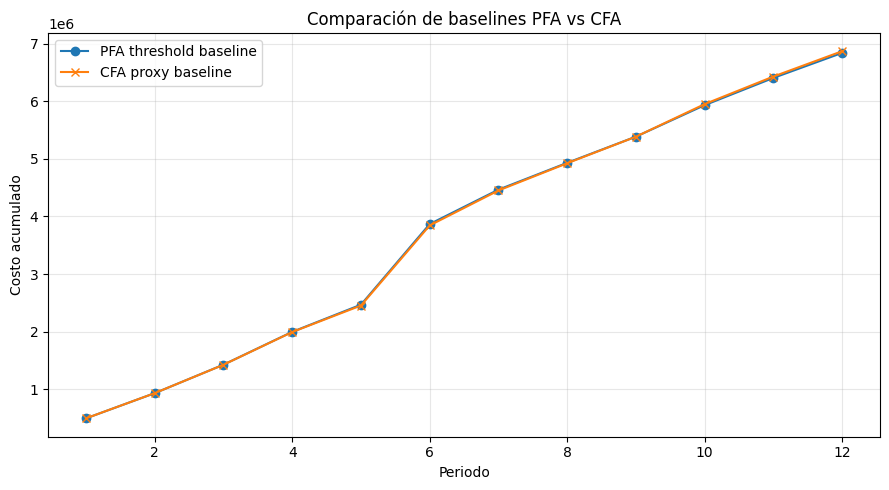

In [25]:
plt.figure(figsize=(9, 5))

plt.plot(
    baseline_pfa_df["t"],
    baseline_pfa_df["cumulative_cost"],
    marker="o",
    label="PFA threshold baseline"
)

plt.plot(
    baseline_cfa_df["t"],
    baseline_cfa_df["cumulative_cost"],
    marker="x",
    label="CFA proxy baseline"
)

plt.xlabel("Periodo")
plt.ylabel("Costo acumulado")
plt.title("Comparación de baselines PFA vs CFA")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 VFA — Value Function Approximation 

In [26]:
def discretize_state(state):
    """
    Estado discreto para VI y Q-learning.
    """

    failed = sum(state["failed"].values())
    reinforced = sum(state["reinforced"].values())
    budget = state["budget_remaining"]
    deficit = state["cumulative_deficit"]
    crisis = int(state["crisis"])

    failed_bin = min(failed // 10, 5)
    reinforced_bin = min(reinforced // 5, 5)

    if budget > 1500:
        budget_bin = 2
    elif budget > 500:
        budget_bin = 1
    else:
        budget_bin = 0

    if deficit == 0:
        deficit_bin = 0
    elif deficit < 500:
        deficit_bin = 1
    else:
        deficit_bin = 2

    return (crisis, failed_bin, reinforced_bin, budget_bin, deficit_bin)

In [27]:
ACTION_NAMES = [
    "do_nothing",
    "repair_failed",
    "reinforce_low_capacity",
    "repair_and_reinforce"
]

In [28]:
def build_action(action_name, state, W, nodes, edges, H_e, max_edges=3):
    """
    Construye una acción completa con 4 decisiones:
    - reinforce
    - repair
    - flow
    - generation_dispatch
    """

    edges_list = edges["e_id"].astype(int).tolist()
    nodes_list = nodes["node"].astype(int).tolist()

    action = {
        "reinforce": {e: 0 for e in edges_list},
        "repair": {e: 0 for e in edges_list},
        "flow": {e: 0.0 for e in edges_list},
        "generation_dispatch": {i: 0.0 for i in nodes_list}
    }

    # Generación despachada: usa toda la generación disponible
    for i in nodes_list:
        action["generation_dispatch"][i] = W["G"].get(i, 0.0)

    # Flujo simple: permite flujo proporcional a capacidad disponible
    # Nota: la transición luego valida capacidad y no negatividad.
    for e in edges_list:
        if state["failed"].get(e, 0) == 0:
            action["flow"][e] = 0.25 * state["capacity"].get(e, 0.0)

    if action_name == "do_nothing":
        return action

    if action_name in ["repair_failed", "repair_and_reinforce"]:
        failed_edges = [
            e for e in edges_list
            if state["failed"].get(e, 0) == 1
        ]

        for e in failed_edges[:max_edges]:
            action["repair"][e] = 1

    if action_name in ["reinforce_low_capacity", "repair_and_reinforce"]:
        candidate_edges = [
            e for e in edges_list
            if state["reinforced"].get(e, 0) == 0
        ]

        candidate_edges = sorted(
            candidate_edges,
            key=lambda e: state["capacity"].get(e, 0.0)
        )

        for e in candidate_edges[:max_edges]:
            action["reinforce"][e] = 1

    return action

In [29]:
def representative_state_from_discrete(s_disc, nodes, edges, budget=2000.0):
    """
    Construye un estado continuo representativo para un estado discreto.
    """

    state = initialize_state(nodes, edges, budget=budget)

    crisis, failed_bin, reinforced_bin, budget_bin, deficit_bin = s_disc

    edges_list = edges["e_id"].astype(int).tolist()

    # Fallas representativas
    n_failed = failed_bin * 10
    for e in edges_list[:n_failed]:
        state["failed"][e] = 1
        state["capacity"][e] = 0.0

    # Refuerzos representativos
    n_reinforced = reinforced_bin * 5
    for e in edges_list[:n_reinforced]:
        state["reinforced"][e] = 1

    # Presupuesto representativo
    if budget_bin == 2:
        state["budget_remaining"] = 1800
    elif budget_bin == 1:
        state["budget_remaining"] = 1000
    else:
        state["budget_remaining"] = 200

    # Déficit representativo
    if deficit_bin == 0:
        state["cumulative_deficit"] = 0
    elif deficit_bin == 1:
        state["cumulative_deficit"] = 250
    else:
        state["cumulative_deficit"] = 1000

    state["crisis"] = bool(crisis)

    return state

In [30]:
def build_W_pool(dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn, n_samples=30):
    """
    Extrae una muestra de realizaciones W para aproximar esperanza en VI.
    """

    available = df_info_dyn[["path", "t"]].drop_duplicates().head(n_samples)

    W_pool = []

    for _, r in available.iterrows():
        W = get_exogenous_info(
            path=int(r["path"]),
            t=int(r["t"]),
            dfD_dyn=dfD_dyn,
            dfU_dyn=dfU_dyn,
            dfc_dyn=dfc_dyn,
            dfG_dyn=dfG_dyn,
            df_info_dyn=df_info_dyn
        )
        W_pool.append(W)

    return W_pool

### Q-Learning

In [31]:
def epsilon_greedy_action(Q, s, epsilon=0.10):
    """
    Selección epsilon-greedy.
    """

    if np.random.rand() < epsilon:
        return np.random.choice(ACTION_NAMES)

    values = [Q.get((s, a), 0.0) for a in ACTION_NAMES]
    return ACTION_NAMES[int(np.argmin(values))]

In [32]:
def q_learning_train(
    nodes,
    edges,
    H_e,
    dfD_dyn,
    dfU_dyn,
    dfc_dyn,
    dfG_dyn,
    df_info_dyn,
    T=12,
    n_episodes=300,
    alpha=0.10,
    gamma=0.95,
    epsilon=0.20,
    budget=2000.0,
    seed=123
):
    """
    Q-learning para minimizar costos.
    """

    rng = np.random.default_rng(seed)
    Q = {}

    episode_returns = []

    available_paths = df_info_dyn["path"].unique()

    for ep in range(n_episodes):
        print(f"Episode {ep+1}/{n_episodes}...")
        path = int(rng.choice(available_paths))

        state = initialize_state(
            nodes=nodes,
            edges=edges,
            budget=budget
        )

        total_return = 0.0

        for t in range(1, T + 1):

            W = get_exogenous_info(
                path=path,
                t=t,
                dfD_dyn=dfD_dyn,
                dfU_dyn=dfU_dyn,
                dfc_dyn=dfc_dyn,
                dfG_dyn=dfG_dyn,
                df_info_dyn=df_info_dyn
            )

            s = discretize_state(state)

            if rng.random() < epsilon:
                a_name = rng.choice(ACTION_NAMES)
            else:
                values = [Q.get((s, a), 0.0) for a in ACTION_NAMES]
                a_name = ACTION_NAMES[int(np.argmin(values))]

            action = build_action(
                action_name=a_name,
                state=state,
                W=W,
                nodes=nodes,
                edges=edges,
                H_e=H_e
            )

            next_state, info = transition(
                state=state,
                action=action,
                W=W,
                nodes=nodes,
                edges=edges,
                H_e=H_e
            )

            cost = info["cost_breakdown"]["total_cost"]
            total_return += cost

            s_next = discretize_state(next_state)

            best_next = min(
                Q.get((s_next, a_next), 0.0)
                for a_next in ACTION_NAMES
            )

            old_q = Q.get((s, a_name), 0.0)

            Q[(s, a_name)] = old_q + alpha * (
                cost + gamma * best_next - old_q
            )

            state = next_state

        episode_returns.append(total_return)

        if (ep + 1) % 25 == 0:
            print(f"Episode {ep+1}/{n_episodes} | return = {total_return:.2f}")

    return Q, episode_returns

In [33]:
Q, q_returns = q_learning_train(
    nodes=nodes,
    edges=edges,
    H_e=H_e,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    T=12,
    n_episodes=100,   # más episodios
    alpha=0.05,        # menor tasa de aprendizaje
    gamma=0.90,        # menos peso al futuro lejano
    epsilon=0.30,      # más exploración inicial
    budget=2000.0,
    seed=2026
)

Episode 1/100...
Episode 2/100...
Episode 3/100...
Episode 4/100...
Episode 5/100...
Episode 6/100...
Episode 7/100...
Episode 8/100...
Episode 9/100...
Episode 10/100...
Episode 11/100...
Episode 12/100...
Episode 13/100...
Episode 14/100...
Episode 15/100...
Episode 16/100...
Episode 17/100...
Episode 18/100...
Episode 19/100...
Episode 20/100...
Episode 21/100...
Episode 22/100...
Episode 23/100...
Episode 24/100...
Episode 25/100...
Episode 25/100 | return = 19463090.89
Episode 26/100...
Episode 27/100...
Episode 28/100...
Episode 29/100...
Episode 30/100...
Episode 31/100...
Episode 32/100...
Episode 33/100...
Episode 34/100...
Episode 35/100...
Episode 36/100...
Episode 37/100...
Episode 38/100...
Episode 39/100...
Episode 40/100...
Episode 41/100...
Episode 42/100...
Episode 43/100...
Episode 44/100...
Episode 45/100...
Episode 46/100...
Episode 47/100...
Episode 48/100...
Episode 49/100...
Episode 50/100...
Episode 50/100 | return = 11548421.97
Episode 51/100...
Episode 52/100.

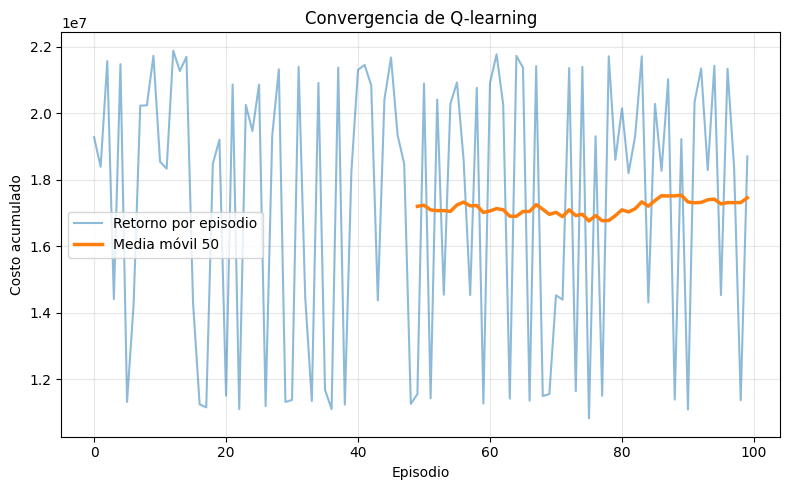

In [34]:
plt.figure(figsize=(8,5))
plt.plot(q_returns, alpha=0.5, label="Retorno por episodio")

window = 50
if len(q_returns) >= window:
    moving_avg = pd.Series(q_returns).rolling(window).mean()
    plt.plot(moving_avg, linewidth=2.5, label=f"Media móvil {window}")

plt.xlabel("Episodio")
plt.ylabel("Costo acumulado")
plt.title("Convergencia de Q-learning")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
def q_learning_policy_fn(state, W, nodes, edges, H_e, params=None):
    """
    Política greedy a partir de Q-learning.
    """

    Q = params["Q"]

    s = discretize_state(state)

    values = [Q.get((s, a), 0.0) for a in ACTION_NAMES]
    best_action_name = ACTION_NAMES[int(np.argmin(values))]

    return build_action(
        action_name=best_action_name,
        state=state,
        W=W,
        nodes=nodes,
        edges=edges,
        H_e=H_e
    )

In [36]:
episode_q = run_episode(
    policy_fn=q_learning_policy_fn,
    path=0,
    T=12,
    nodes=nodes,
    edges=edges,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    H_e=H_e,
    budget=2000.0,
    policy_params={"Q": Q}
)

episode_q

,path,t,crisis,budget_remaining,period_cost,operating_cost,reinforcement_cost,repair_cost,deficit_cost,total_deficit,served_demand,total_flow,total_generation_dispatch,num_failed_edges,num_reinforced_edges,action_reinforce,action_repair,cumulative_cost,cumulative_deficit
0,0,1,False,1850.0,1.527946e+06,1.067435e+06,150.0,0.0,4.603611e+05,2422.952983,900.862139,19746.75,7760.049336,4,3,"[61, 94, 96]",[],1.527946e+06,2422.952983
1,0,2,False,1625.0,1.623656e+06,1.207395e+06,150.0,75.0,4.160360e+05,2189.663089,756.300705,19699.25,7628.866382,3,6,"[102, 139, 148]","[102, 139, 148]",3.151603e+06,4612.616072
2,0,3,False,1550.0,1.643924e+06,1.185922e+06,0.0,75.0,4.579270e+05,2410.142278,910.115889,19887.95,7597.748409,3,6,[],"[39, 57, 174]",4.795527e+06,7022.758350
3,0,4,False,1475.0,1.732445e+06,1.220448e+06,0.0,75.0,5.119217e+05,2694.324866,962.445009,20083.95,7641.660269,4,6,[],"[76, 99, 138]",6.527972e+06,9717.083217
4,0,5,False,1400.0,1.594919e+06,1.172568e+06,0.0,75.0,4.222755e+05,2222.502634,793.233067,20205.95,7560.929300,2,6,[],"[31, 38, 124]",8.122891e+06,11939.585850
5,0,6,True,1350.0,3.408463e+06,2.263713e+06,0.0,50.0,1.144699e+06,6024.733696,2075.278218,17224.45,7686.697248,36,6,[],"[142, 167]",1.153135e+07,17964.319546
6,0,7,False,1275.0,1.640404e+06,1.163851e+06,0.0,75.0,4.764783e+05,2507.780415,1181.833536,17159.45,7681.694526,36,6,[],"[0, 1, 7]",1.317176e+07,20472.099962
7,0,8,False,1125.0,1.413738e+06,1.049750e+06,150.0,0.0,3.638375e+05,1914.934122,948.957416,17402.20,7637.659839,39,9,"[11, 13, 20]",[],1.458550e+07,22387.034084
8,0,9,False,975.0,1.355305e+06,9.918348e+05,150.0,0.0,3.633203e+05,1912.212264,928.273903,16021.25,7865.551006,45,12,"[27, 30, 35]",[],1.594080e+07,24299.246348
9,0,10,False,975.0,1.523292e+06,1.079564e+06,0.0,0.0,4.437283e+05,2335.411883,1088.695932,15949.75,7583.248698,46,12,[],[],1.746409e+07,26634.658231


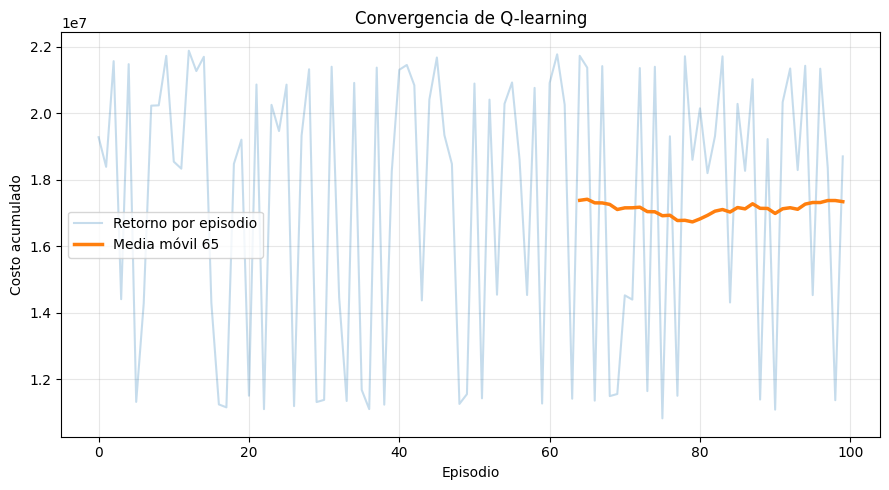

In [37]:
plt.figure(figsize=(9,5))
plt.plot(q_returns, alpha=0.25, label="Retorno por episodio")

moving_avg = pd.Series(q_returns).rolling(65).mean()
plt.plot(moving_avg, linewidth=2.5, label="Media móvil 65")

plt.xlabel("Episodio")
plt.ylabel("Costo acumulado")
plt.title("Convergencia de Q-learning")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
initial_avg = np.mean(q_returns[:50])
final_avg = np.mean(q_returns[-50:])

improvement = 100 * (initial_avg - final_avg) / initial_avg

print("Promedio inicial:", initial_avg)
print("Promedio final:", final_avg)
print("Mejora (%):", improvement)

Promedio inicial: 17198953.30171518
Promedio final: 17454984.410401836
Mejora (%): -1.488643548215942


In [39]:
policy_rows = []

for s in sorted(set([key[0] for key in Q.keys()])):
    values = {a: Q.get((s, a), 0.0) for a in ACTION_NAMES}
    best_action = min(values, key=values.get)

    policy_rows.append({
        "crisis": s[0],
        "failed_bin": s[1],
        "reinforced_bin": s[2],
        "budget_bin": s[3],
        "deficit_bin": s[4],
        "best_action": best_action,
        **values
    })

policy_df = pd.DataFrame(policy_rows)
policy_df.head()

,crisis,failed_bin,reinforced_bin,budget_bin,deficit_bin,best_action,do_nothing,repair_failed,reinforce_low_capacity,repair_and_reinforce
0,0,0,0,2,0,reinforce_low_capacity,2.317053e+06,2.403746e+06,2.284981e+06,2.358065e+06
1,0,0,0,2,2,repair_and_reinforce,2.769453e+06,2.749610e+06,2.721900e+06,2.721208e+06
2,0,0,1,1,2,repair_failed,8.842100e+05,8.652338e+05,9.859068e+05,9.539192e+05
3,0,0,1,2,2,repair_failed,1.529474e+06,1.526357e+06,1.540994e+06,1.546948e+06
4,0,0,2,1,2,do_nothing,4.848613e+05,6.240454e+05,4.851382e+05,5.880290e+05


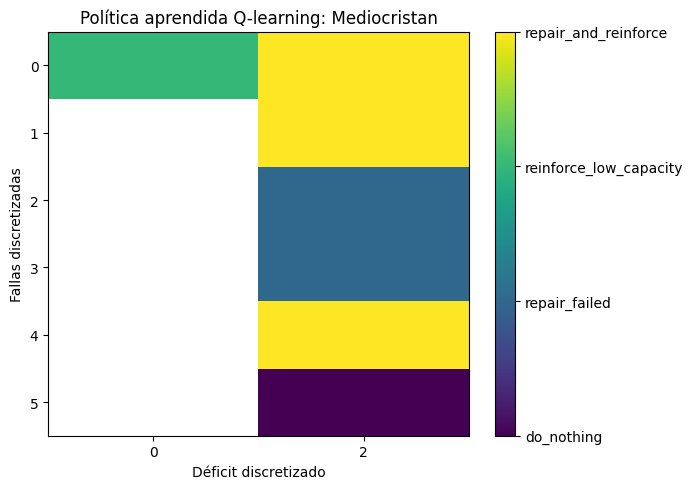

In [40]:
action_to_num = {a: i for i, a in enumerate(ACTION_NAMES)}

df_plot = policy_df.copy()
df_plot["action_num"] = df_plot["best_action"].map(action_to_num)

# Fijamos crisis=0, presupuesto alto, refuerzos bajos
subset = df_plot[
    (df_plot["crisis"] == 0) &
    (df_plot["budget_bin"] == 2) &
    (df_plot["reinforced_bin"] == 0)
]

pivot = subset.pivot_table(
    index="failed_bin",
    columns="deficit_bin",
    values="action_num",
    aggfunc="first"
)

plt.figure(figsize=(7,5))
plt.imshow(pivot, aspect="auto")

plt.xticks(
    ticks=np.arange(len(pivot.columns)),
    labels=pivot.columns
)
plt.yticks(
    ticks=np.arange(len(pivot.index)),
    labels=pivot.index
)

plt.xlabel("Déficit discretizado")
plt.ylabel("Fallas discretizadas")
plt.title("Política aprendida Q-learning: Mediocristan")

cbar = plt.colorbar()
cbar.set_ticks(list(action_to_num.values()))
cbar.set_ticklabels(list(action_to_num.keys()))

plt.tight_layout()
plt.show()

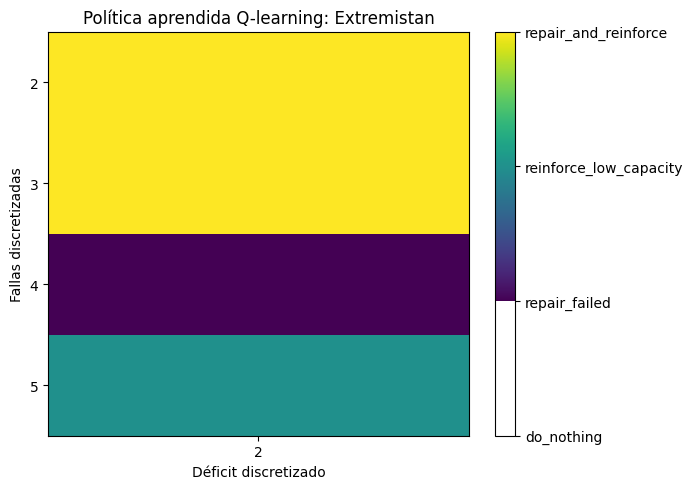

In [41]:
subset = df_plot[
    (df_plot["crisis"] == 1) &
    (df_plot["budget_bin"] == 2) &
    (df_plot["reinforced_bin"] == 0)
]

pivot = subset.pivot_table(
    index="failed_bin",
    columns="deficit_bin",
    values="action_num",
    aggfunc="first"
)

plt.figure(figsize=(7,5))
plt.imshow(pivot, aspect="auto")

plt.xticks(np.arange(len(pivot.columns)), pivot.columns)
plt.yticks(np.arange(len(pivot.index)), pivot.index)

plt.xlabel("Déficit discretizado")
plt.ylabel("Fallas discretizadas")
plt.title("Política aprendida Q-learning: Extremistan")

cbar = plt.colorbar()
cbar.set_ticks(list(action_to_num.values()))
cbar.set_ticklabels(list(action_to_num.keys()))

plt.tight_layout()
plt.show()

## Evaluación

In [42]:
dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn  = generate_dynamic_scenarios(
    nodes=nodes,
    edges=edges,
    T=20,
    n_paths=10,
    seed=2026,
    p_crisis=0.15
)

df_info_dyn 

,path,t,crisis,dem_mult,cost_mult
0,0,1,False,1.024057,0.905184
1,0,2,False,0.907642,1.024866
2,0,3,False,1.022961,1.005959
3,0,4,False,1.126639,1.028948
4,0,5,False,0.929139,0.987031
...,...,...,...,...,...
195,9,16,False,0.925201,1.025112
196,9,17,True,1.629118,2.000000
197,9,18,False,0.745267,0.965889
198,9,19,True,1.912013,2.000000


In [43]:
path_summary = (
    df_info_dyn
    .groupby("path")
    .agg(
        crisis_share=("crisis", "mean"),
        n_periods=("t", "count")
    )
    .reset_index()
)

paths_med = path_summary.loc[
    path_summary["crisis_share"] <= 0.10,
    "path"
].tolist()

paths_ext = path_summary.loc[
    path_summary["crisis_share"] > 0.10,
    "path"
].tolist()

paths_mix = path_summary["path"].tolist()

print("Paths mix:", len(paths_mix))
print("Paths Mediocristan:", len(paths_med))
print("Paths Extremistan:", len(paths_ext))

Paths mix: 10
Paths Mediocristan: 6
Paths Extremistan: 4


In [44]:
df_info_mix = df_info_dyn[df_info_dyn["path"].isin(paths_mix)].copy()
df_info_med = df_info_dyn[df_info_dyn["path"].isin(paths_med)].copy()
df_info_ext = df_info_dyn[df_info_dyn["path"].isin(paths_ext)].copy()

print("Filas mix:", len(df_info_mix))
print("Filas med:", len(df_info_med))
print("Filas ext:", len(df_info_ext))

Filas mix: 200
Filas med: 120
Filas ext: 80


In [45]:
T_MODEL = 20
N_PATHS = 10


In [47]:
# ============================================================
# Política 1: entrenada con mezcla de escenarios
# ============================================================

Q_mix, returns_mix  = q_learning_train(
    nodes=nodes,
    edges=edges,
    H_e=H_e,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_mix,
    T=T_MODEL,
    n_episodes=100,
    alpha=0.05,       
    gamma=0.90,       
    epsilon=0.30,     
    budget=2000.0,
    seed=2026
)

Episode 1/100...
Episode 2/100...
Episode 3/100...
Episode 4/100...
Episode 5/100...
Episode 6/100...
Episode 7/100...
Episode 8/100...
Episode 9/100...
Episode 10/100...
Episode 11/100...
Episode 12/100...
Episode 13/100...
Episode 14/100...
Episode 15/100...
Episode 16/100...
Episode 17/100...
Episode 18/100...
Episode 19/100...
Episode 20/100...
Episode 21/100...
Episode 22/100...
Episode 23/100...
Episode 24/100...
Episode 25/100...
Episode 25/100 | return = 30216977.04
Episode 26/100...
Episode 27/100...
Episode 28/100...
Episode 29/100...
Episode 30/100...
Episode 31/100...
Episode 32/100...
Episode 33/100...
Episode 34/100...
Episode 35/100...
Episode 36/100...
Episode 37/100...
Episode 38/100...
Episode 39/100...
Episode 40/100...
Episode 41/100...
Episode 42/100...
Episode 43/100...
Episode 44/100...
Episode 45/100...
Episode 46/100...
Episode 47/100...
Episode 48/100...
Episode 49/100...
Episode 50/100...
Episode 50/100 | return = 30419311.84
Episode 51/100...
Episode 52/100.

In [48]:
# ============================================================
# Política 2: entrenada solo con Mediocristan
# ============================================================

Q_med, returns_med = q_learning_train(
    nodes=nodes,
    edges=edges,
    H_e=H_e,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_med,
    T=T_MODEL,
    n_episodes=100,
    alpha=0.05,
    gamma=0.90,
    epsilon=0.30,
    budget=2000.0,
    seed=2027
)

Episode 1/100...
Episode 2/100...
Episode 3/100...
Episode 4/100...
Episode 5/100...
Episode 6/100...
Episode 7/100...
Episode 8/100...
Episode 9/100...
Episode 10/100...
Episode 11/100...
Episode 12/100...
Episode 13/100...
Episode 14/100...
Episode 15/100...
Episode 16/100...
Episode 17/100...
Episode 18/100...
Episode 19/100...
Episode 20/100...
Episode 21/100...
Episode 22/100...
Episode 23/100...
Episode 24/100...
Episode 25/100...
Episode 25/100 | return = 23070115.19
Episode 26/100...
Episode 27/100...
Episode 28/100...
Episode 29/100...
Episode 30/100...
Episode 31/100...
Episode 32/100...
Episode 33/100...
Episode 34/100...
Episode 35/100...
Episode 36/100...
Episode 37/100...
Episode 38/100...
Episode 39/100...
Episode 40/100...
Episode 41/100...
Episode 42/100...
Episode 43/100...
Episode 44/100...
Episode 45/100...
Episode 46/100...
Episode 47/100...
Episode 48/100...
Episode 49/100...
Episode 50/100...
Episode 50/100 | return = 33674566.52
Episode 51/100...
Episode 52/100.

In [49]:
# ============================================================
# Política 3: entrenada solo con Extremistan
# ============================================================

Q_ext, returns_ext = q_learning_train(
    nodes=nodes,
    edges=edges,
    H_e=H_e,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_ext,
    T=T_MODEL,
    n_episodes=100,
    alpha=0.05,
    gamma=0.90,
    epsilon=0.30,
    budget=2000.0,
    seed=2028
)

Episode 1/100...
Episode 2/100...
Episode 3/100...
Episode 4/100...
Episode 5/100...
Episode 6/100...
Episode 7/100...
Episode 8/100...
Episode 9/100...
Episode 10/100...
Episode 11/100...
Episode 12/100...
Episode 13/100...
Episode 14/100...
Episode 15/100...
Episode 16/100...
Episode 17/100...
Episode 18/100...
Episode 19/100...
Episode 20/100...
Episode 21/100...
Episode 22/100...
Episode 23/100...
Episode 24/100...
Episode 25/100...
Episode 25/100 | return = 22197285.46
Episode 26/100...
Episode 27/100...
Episode 28/100...
Episode 29/100...
Episode 30/100...
Episode 31/100...
Episode 32/100...
Episode 33/100...
Episode 34/100...
Episode 35/100...
Episode 36/100...
Episode 37/100...
Episode 38/100...
Episode 39/100...
Episode 40/100...
Episode 41/100...
Episode 42/100...
Episode 43/100...
Episode 44/100...
Episode 45/100...
Episode 46/100...
Episode 47/100...
Episode 48/100...
Episode 49/100...
Episode 50/100...
Episode 50/100 | return = 29641724.29
Episode 51/100...
Episode 52/100.

### Convergencias Comparadas

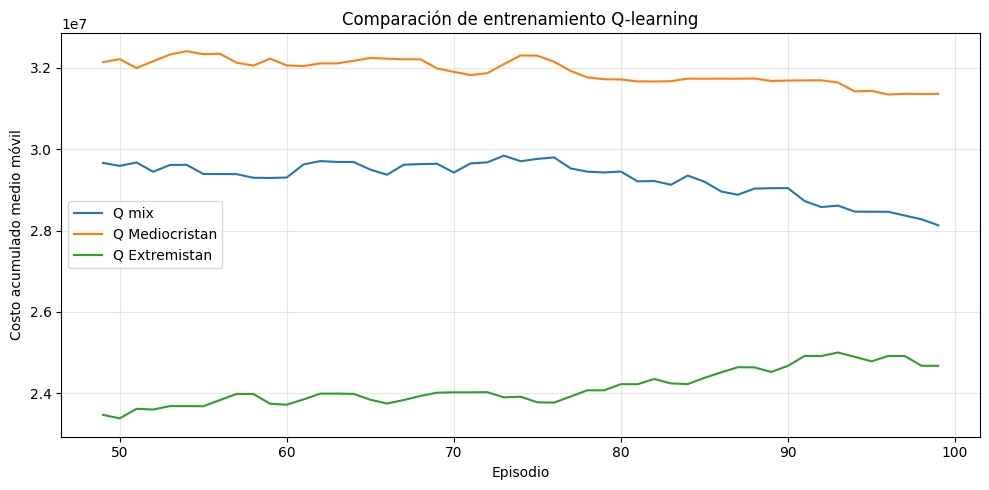

In [50]:
plt.figure(figsize=(10, 5))

window = 50

plt.plot(pd.Series(returns_mix).rolling(window).mean(), label="Q mix")
plt.plot(pd.Series(returns_med).rolling(window).mean(), label="Q Mediocristan")
plt.plot(pd.Series(returns_ext).rolling(window).mean(), label="Q Extremistan")

plt.xlabel("Episodio")
plt.ylabel("Costo acumulado medio móvil")
plt.title("Comparación de entrenamiento Q-learning")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
def make_q_policy(Q_table):
    def policy_fn(state, W, nodes, edges, H_e, params=None):
        return q_learning_policy_fn(
            state=state,
            W=W,
            nodes=nodes,
            edges=edges,
            H_e=H_e,
            params={"Q": Q_table}
        )
    return policy_fn


policy_mix = make_q_policy(Q_mix)
policy_med = make_q_policy(Q_med)
policy_ext = make_q_policy(Q_ext)

In [52]:
def evaluate_policy_on_paths(
    policy_fn,
    policy_name,
    paths,
    T,
    nodes,
    edges,
    dfD_dyn,
    dfU_dyn,
    dfc_dyn,
    dfG_dyn,
    df_info_dyn,
    H_e,
    budget=2000.0
):
    rows = []

    for path in paths:
        ep = run_episode(
            policy_fn=policy_fn,
            path=int(path),
            T=T,
            nodes=nodes,
            edges=edges,
            dfD_dyn=dfD_dyn,
            dfU_dyn=dfU_dyn,
            dfc_dyn=dfc_dyn,
            dfG_dyn=dfG_dyn,
            df_info_dyn=df_info_dyn,
            H_e=H_e,
            budget=budget
        )

        rows.append({
            "policy": policy_name,
            "path": int(path),
            "total_cost": ep["period_cost"].sum(),
            "total_deficit": ep["total_deficit"].sum(),
            "final_budget": ep["budget_remaining"].iloc[-1],
            "max_failed_edges": ep["num_failed_edges"].max(),
            "final_reinforced": ep["num_reinforced_edges"].iloc[-1],
            "crisis_share": ep["crisis"].mean()
        })

    return pd.DataFrame(rows)

In [53]:
eval_all = pd.concat([
    evaluate_policy_on_paths(policy_mix, "Q_mix", paths_mix, T_MODEL, nodes, edges, dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn, H_e),
    evaluate_policy_on_paths(policy_med, "Q_med", paths_mix, T_MODEL, nodes, edges, dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn, H_e),
    evaluate_policy_on_paths(policy_ext, "Q_ext", paths_mix, T_MODEL, nodes, edges, dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn, H_e),
], ignore_index=True)

eval_all.head()

,policy,path,total_cost,total_deficit,final_budget,max_failed_edges,final_reinforced,crisis_share
0,Q_mix,0,3.457225e+07,52793.051361,425.0,75,18,0.10
1,Q_mix,1,2.308910e+07,52793.016363,1025.0,94,12,0.10
2,Q_mix,2,2.299158e+07,54449.731549,1175.0,115,12,0.15
3,Q_mix,3,2.974590e+07,53633.430692,1025.0,125,12,0.15
4,Q_mix,4,3.425695e+07,51609.003538,350.0,49,9,0.05


In [54]:
summary_q_policies = (
    eval_all
    .groupby("policy")
    .agg(
        costo_promedio=("total_cost", "mean"),
        costo_p95=("total_cost", lambda x: np.percentile(x, 95)),
        costo_max=("total_cost", "max"),
        deficit_promedio=("total_deficit", "mean"),
        presupuesto_final_promedio=("final_budget", "mean"),
        refuerzos_finales_promedio=("final_reinforced", "mean")
    )
    .reset_index()
)

summary_q_policies

,policy,costo_promedio,costo_p95,costo_max,deficit_promedio,presupuesto_final_promedio,refuerzos_finales_promedio
0,Q_ext,2.807216e+07,3.446956e+07,3.447228e+07,53006.787004,847.5,6.6
1,Q_med,2.800859e+07,3.473349e+07,3.487492e+07,53149.068268,742.5,15.0
2,Q_mix,2.812400e+07,3.457825e+07,3.458315e+07,53361.370326,870.0,12.3


C:\Users\sofia\AppData\Local\Temp\ipykernel_14160\920273333.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=eval_all["policy"].unique(), showmeans=True)


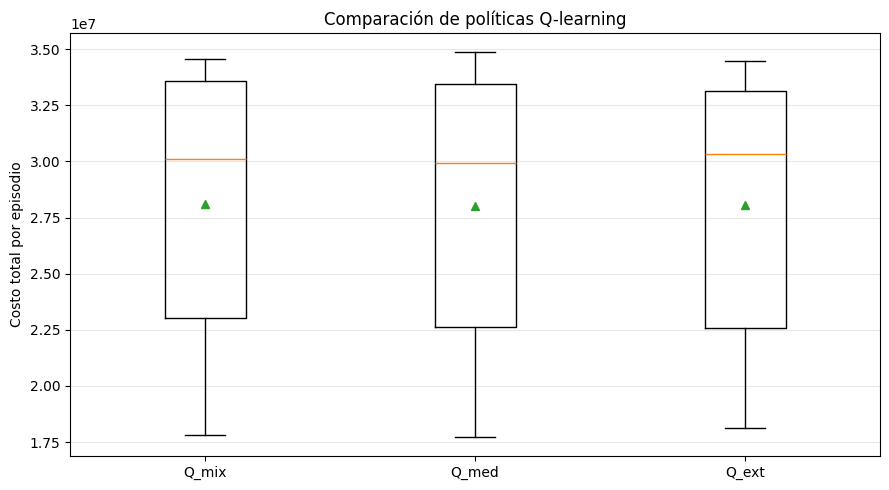

In [55]:
plt.figure(figsize=(9, 5))

data = [
    eval_all.loc[eval_all["policy"] == p, "total_cost"].values
    for p in eval_all["policy"].unique()
]

plt.boxplot(data, labels=eval_all["policy"].unique(), showmeans=True)

plt.ylabel("Costo total por episodio")
plt.title("Comparación de políticas Q-learning")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
def compute_learning_improvement(returns, window=50, policy_name="Q"):
    initial_avg = np.mean(returns[:window])
    final_avg = np.mean(returns[-window:])

    improvement = 100 * (initial_avg - final_avg) / initial_avg

    return {
        "Política": policy_name,
        "Promedio inicial": initial_avg,
        "Promedio final": final_avg,
        "Mejora (%)": improvement
    }


improvement_table = pd.DataFrame([
    compute_learning_improvement(returns_mix, window=75, policy_name="Q_mix"),
    compute_learning_improvement(returns_med, window=75, policy_name="Q_med"),
    compute_learning_improvement(returns_ext, window=75, policy_name="Q_ext")
])

improvement_table
improvement_table_fmt = improvement_table.copy()

for col in ["Promedio inicial", "Promedio final", "Mejora (%)"]:
    improvement_table_fmt[col] = improvement_table_fmt[col].map(lambda x: f"{x:,.2f}")

improvement_table_fmt

,Política,Promedio inicial,Promedio final,Mejora (%)
0,Q_mix,"29,486,544.02","28,847,659.69",2.17
1,Q_med,"31,822,356.48","32,050,268.54",-0.72
2,Q_ext,"23,873,068.46","24,168,546.84",-1.24


In [57]:
def build_policy_df_from_Q(Q, policy_name="Q"):
    """
    Convierte una Q-table en una tabla de política greedy.
    Compatible con el estado:
    (crisis, failed_bin, reinforced_bin, budget_bin, deficit_bin)
    """

    rows = []
    visited_states = sorted({s for (s, a) in Q.keys()})

    for s in visited_states:
        values = [Q.get((s, a), 0.0) for a in ACTION_NAMES]
        best_action = ACTION_NAMES[int(np.argmin(values))]

        crisis, failed_bin, reinforced_bin, budget_bin, deficit_bin = s

        rows.append({
            "policy": policy_name,
            "crisis": crisis,
            "failed_bin": failed_bin,
            "reinforced_bin": reinforced_bin,
            "budget_bin": budget_bin,
            "deficit_bin": deficit_bin,
            "best_action": best_action
        })

    return pd.DataFrame(rows)

In [58]:
def plot_q_heatmap(
    Q,
    policy_name,
    crisis_value=0,
    budget_bin=2,
    reinforced_bin=0
):
    """
    Heatmap de decisiones aprendidas.
    """

    policy_df = build_policy_df_from_Q(Q, policy_name=policy_name)

    action_to_num = {a: i for i, a in enumerate(ACTION_NAMES)}
    num_to_action = {i: a for a, i in action_to_num.items()}

    df_plot = policy_df.copy()
    df_plot["action_num"] = df_plot["best_action"].map(action_to_num)

    subset = df_plot[
        (df_plot["crisis"] == crisis_value) &
        (df_plot["budget_bin"] == budget_bin) &
        (df_plot["reinforced_bin"] == reinforced_bin)
    ]

    pivot = subset.pivot_table(
        index="failed_bin",
        columns="deficit_bin",
        values="action_num",
        aggfunc="first"
    )

    pivot = pivot.reindex(
        index=sorted(policy_df["failed_bin"].unique()),
        columns=sorted(policy_df["deficit_bin"].unique())
    )

    data = np.ma.masked_invalid(pivot.values)

    cmap = ListedColormap([
        "#2E3440",
        "#5E81AC",
        "#A3BE8C",
        "#EBCB8B",
        "#BF616A",
        "#B48EAD"
    ][:len(ACTION_NAMES)])

    cmap.set_bad(color="#E5E9F0")

    norm = BoundaryNorm(
        boundaries=np.arange(-0.5, len(ACTION_NAMES) + 0.5, 1),
        ncolors=len(ACTION_NAMES)
    )

    regime = "Mediocristan" if crisis_value == 0 else "Extremistan"

    plt.figure(figsize=(8.5, 5.5))
    im = plt.imshow(data, aspect="auto", cmap=cmap, norm=norm)

    plt.xticks(
        ticks=np.arange(len(pivot.columns)),
        labels=pivot.columns
    )

    plt.yticks(
        ticks=np.arange(len(pivot.index)),
        labels=pivot.index
    )

    plt.xlabel("Déficit acumulado discretizado")
    plt.ylabel("Fallas discretizadas")
    plt.title(f"{policy_name} | Política aprendida en {regime}")

    cbar = plt.colorbar(im)
    cbar.set_ticks(list(action_to_num.values()))
    cbar.set_ticklabels([num_to_action[i] for i in range(len(ACTION_NAMES))])

    plt.tight_layout()
    plt.show()

    print(f"\nResumen acciones {policy_name} - {regime}")
    print(subset["best_action"].value_counts())

In [59]:
def get_episode_actions_summary(episode_df):
    """
    Extrae arcos reforzados y reparados durante un episodio.
    """

    reinforced = []
    repaired = []

    for _, row in episode_df.iterrows():
        reinforced += row["action_reinforce"]
        repaired += row["action_repair"]

    reinforced = sorted(list(set(reinforced)))
    repaired = sorted(list(set(repaired)))

    return reinforced, repaired

In [60]:
episode_mix = run_episode(
    policy_fn=policy_mix,
    path=0,
    T=T_MODEL,
    nodes=nodes,
    edges=edges,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    H_e=H_e,
    budget=2000.0
)

episode_med = run_episode(
    policy_fn=policy_med,
    path=0,
    T=T_MODEL,
    nodes=nodes,
    edges=edges,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    H_e=H_e,
    budget=2000.0
)

episode_ext = run_episode(
    policy_fn=policy_ext,
    path=0,
    T=T_MODEL,
    nodes=nodes,
    edges=edges,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    H_e=H_e,
    budget=2000.0
)

In [61]:
def plot_policy_network(
    nodes,
    edges,
    episode_df,
    title="Red con decisiones de política",
    figsize=(12, 9),
    seed=7
):
    """
    Grafica la red resaltando:
    - arcos reforzados
    - arcos reparados
    - arcos fallados finales
    - generadores
    """

    reinforced_edges, repaired_edges = get_episode_actions_summary(episode_df)

    final_failed_count = episode_df["num_failed_edges"].iloc[-1]
    final_reinforced_count = episode_df["num_reinforced_edges"].iloc[-1]

    G = nx.Graph()

    for _, r in nodes.iterrows():
        node = int(r["node"])
        is_gen = bool(r.get("is_generator", False))
        G.add_node(node, is_generator=is_gen)

    edge_id_to_pair = {}

    for _, r in edges.iterrows():
        e = int(r["e_id"])
        i = int(r["i"])
        j = int(r["j"])
        G.add_edge(i, j, e_id=e)
        edge_id_to_pair[e] = (i, j)

    pos = nx.spring_layout(G, seed=seed, k=0.18)

    gen_nodes = [
        n for n, attr in G.nodes(data=True)
        if attr.get("is_generator", False)
    ]

    demand_nodes = [
        n for n in G.nodes()
        if n not in gen_nodes
    ]

    normal_edges = []
    reinforced_plot_edges = []
    repaired_plot_edges = []
    both_edges = []

    for e, pair in edge_id_to_pair.items():
        is_reinf = e in reinforced_edges
        is_rep = e in repaired_edges

        if is_reinf and is_rep:
            both_edges.append(pair)
        elif is_reinf:
            reinforced_plot_edges.append(pair)
        elif is_rep:
            repaired_plot_edges.append(pair)
        else:
            normal_edges.append(pair)

    plt.figure(figsize=figsize)

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=normal_edges,
        alpha=0.18,
        width=0.8
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=reinforced_plot_edges,
        width=2.8,
        edge_color="#D62728",
        label="Reforzado"
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=repaired_plot_edges,
        width=2.8,
        edge_color="#1F77B4",
        style="dashed",
        label="Reparado"
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=both_edges,
        width=3.2,
        edge_color="#9467BD",
        style="dashdot",
        label="Reforzado y reparado"
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=demand_nodes,
        node_size=55,
        node_color="#D8DEE9",
        edgecolors="#4C566A",
        linewidths=0.4,
        label="Nodos"
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=gen_nodes,
        node_size=130,
        node_color="#A3BE8C",
        edgecolors="#2E3440",
        linewidths=0.8,
        label="Generadores"
    )

    plt.title(
        f"{title}\n"
        f"Reforzados: {len(reinforced_edges)} | "
        f"Reparados: {len(repaired_edges)} | "
        f"Fallas finales: {final_failed_count} | "
        f"Refuerzos finales: {final_reinforced_count}",
        fontsize=13
    )

    plt.axis("off")
    plt.legend(loc="lower left", frameon=True)
    plt.tight_layout()
    plt.show()

    print("Arcos reforzados:", reinforced_edges)
    print("Arcos reparados:", repaired_edges)

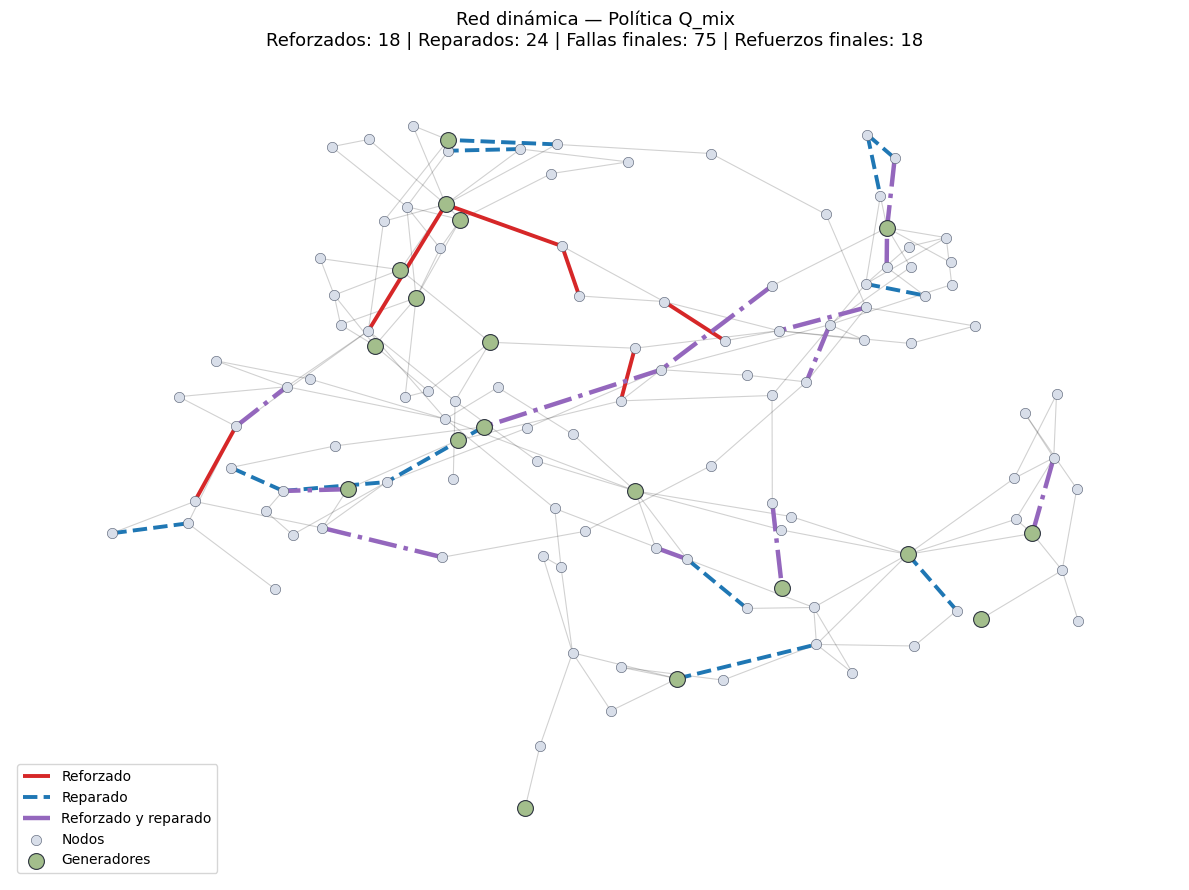

Arcos reforzados: [7, 11, 13, 20, 24, 27, 30, 35, 46, 49, 50, 53, 61, 94, 96, 102, 139, 148]
Arcos reparados: [0, 1, 4, 7, 11, 13, 20, 24, 27, 30, 31, 35, 38, 39, 46, 57, 76, 99, 102, 124, 138, 139, 142, 148]


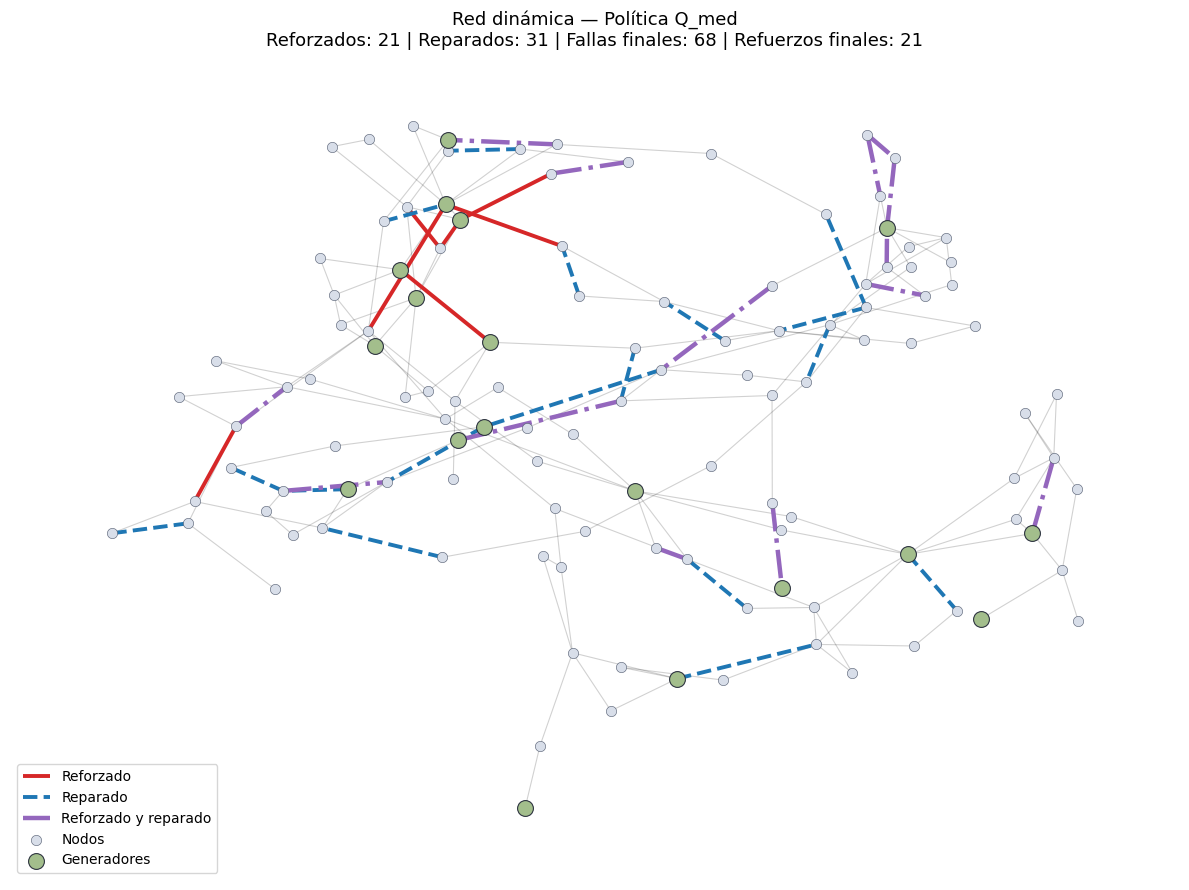

Arcos reforzados: [0, 1, 4, 7, 11, 13, 20, 34, 39, 57, 61, 67, 68, 70, 72, 94, 96, 102, 139, 148, 174]
Arcos reparados: [0, 1, 4, 7, 11, 13, 20, 24, 27, 30, 31, 34, 35, 38, 39, 46, 49, 50, 53, 55, 57, 60, 67, 76, 99, 102, 124, 138, 139, 142, 148]


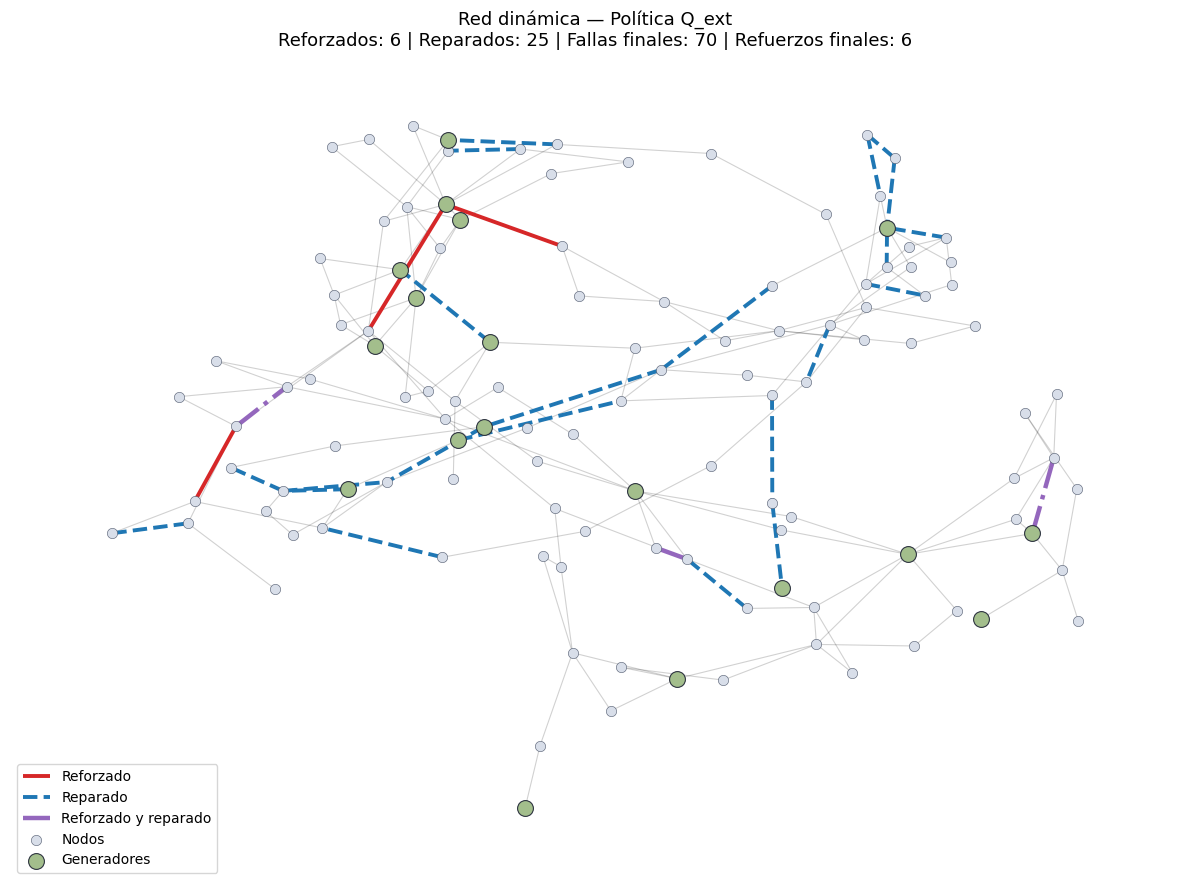

Arcos reforzados: [61, 94, 96, 102, 139, 148]
Arcos reparados: [0, 1, 4, 6, 7, 10, 11, 13, 20, 24, 27, 30, 31, 34, 35, 38, 39, 57, 76, 99, 102, 138, 139, 148, 174]


In [62]:
plot_policy_network(
    nodes=nodes,
    edges=edges,
    episode_df=episode_mix,
    title="Red dinámica — Política Q_mix"
)

plot_policy_network(
    nodes=nodes,
    edges=edges,
    episode_df=episode_med,
    title="Red dinámica — Política Q_med"
)

plot_policy_network(
    nodes=nodes,
    edges=edges,
    episode_df=episode_ext,
    title="Red dinámica — Política Q_ext"
)

In [63]:
def plot_episode_comparison(episodes_dict):
    """
    Compara costo acumulado y déficit acumulado.
    """

    plt.figure(figsize=(9, 5))

    for name, ep in episodes_dict.items():
        plt.plot(
            ep["t"],
            ep["cumulative_cost"],
            marker="o",
            linewidth=2,
            label=name
        )

    plt.xlabel("Periodo")
    plt.ylabel("Costo acumulado")
    plt.title("Costo acumulado por política")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 5))

    for name, ep in episodes_dict.items():
        plt.plot(
            ep["t"],
            ep["cumulative_deficit"],
            marker="o",
            linewidth=2,
            label=name
        )

    plt.xlabel("Periodo")
    plt.ylabel("Déficit acumulado")
    plt.title("Déficit acumulado por política")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

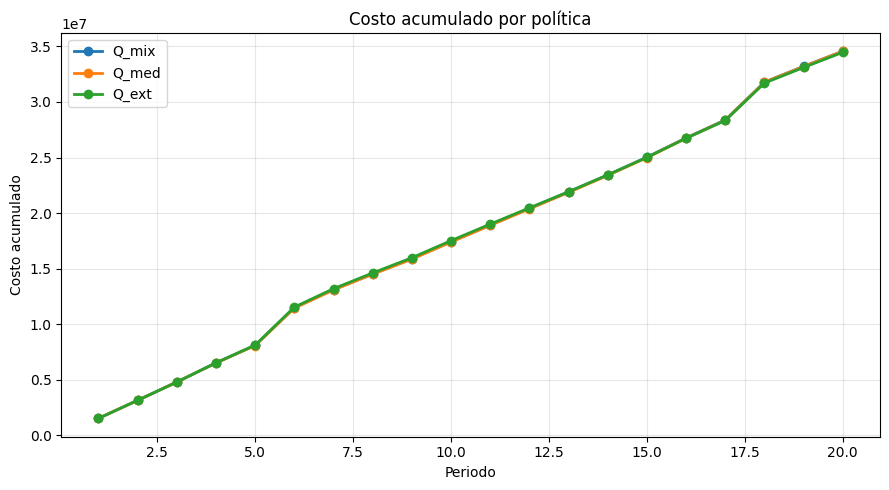

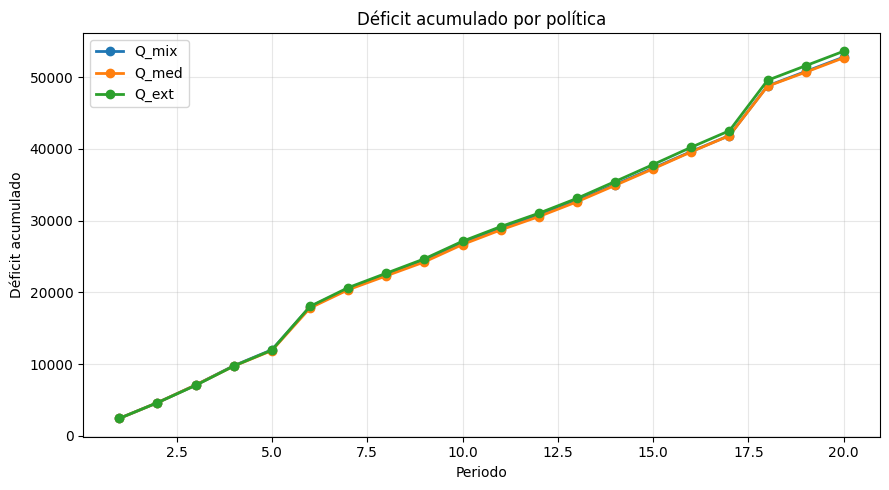

In [64]:
plot_episode_comparison({
    "Q_mix": episode_mix,
    "Q_med": episode_med,
    "Q_ext": episode_ext
})

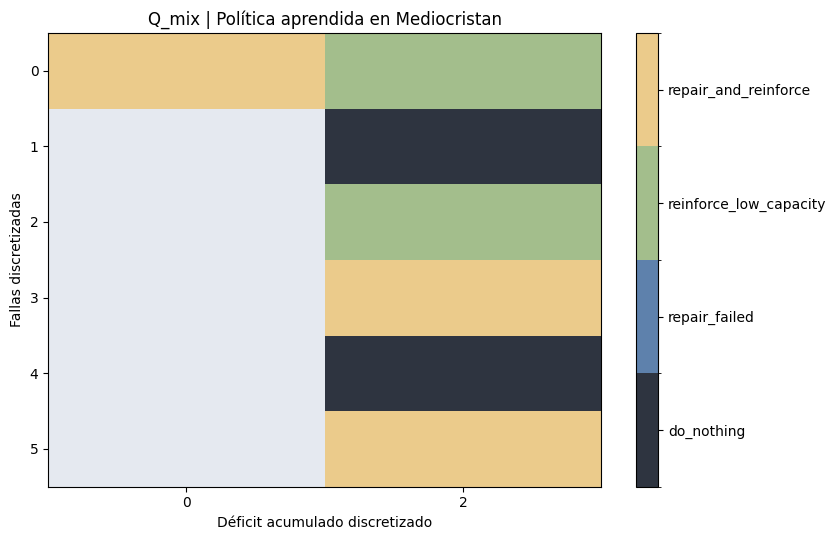


Resumen acciones Q_mix - Mediocristan
best_action
repair_and_reinforce      3
reinforce_low_capacity    2
do_nothing                2
Name: count, dtype: int64


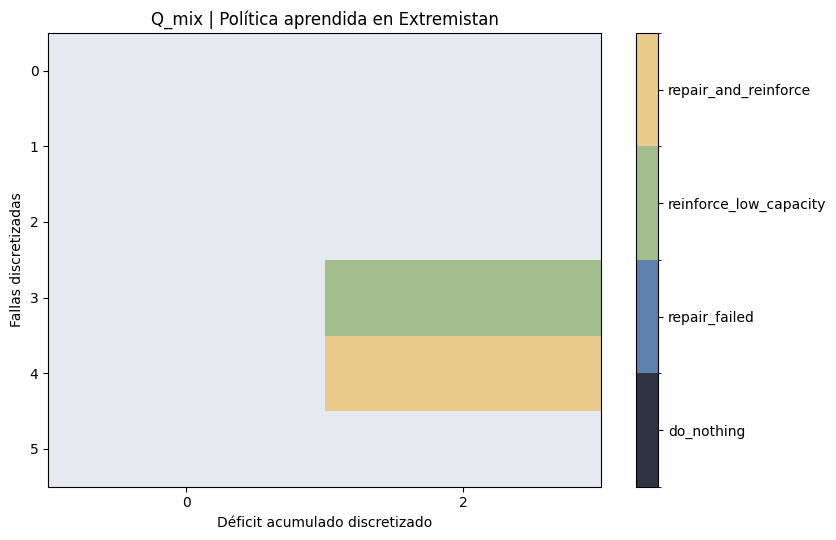


Resumen acciones Q_mix - Extremistan
best_action
reinforce_low_capacity    1
repair_and_reinforce      1
Name: count, dtype: int64


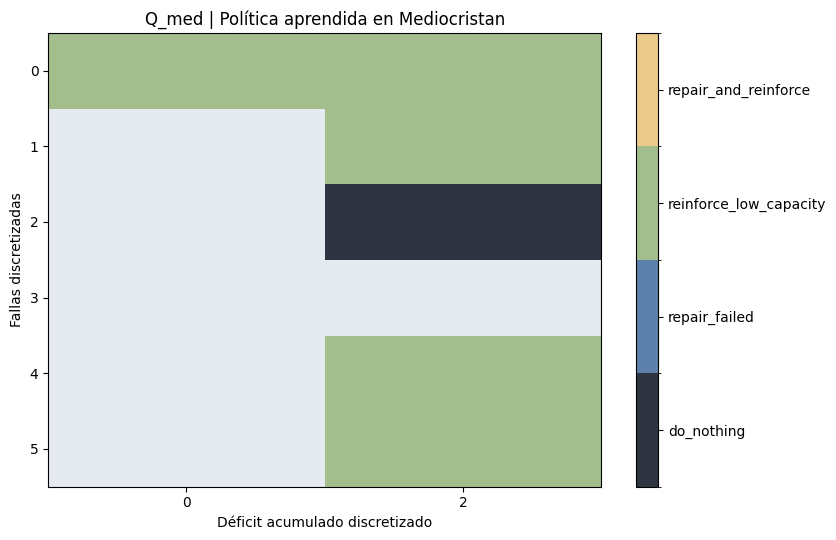


Resumen acciones Q_med - Mediocristan
best_action
reinforce_low_capacity    5
do_nothing                1
Name: count, dtype: int64


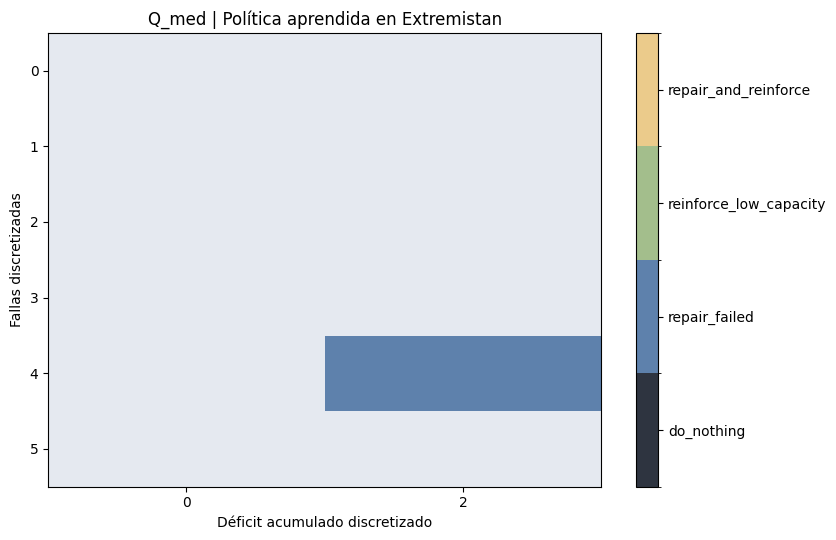


Resumen acciones Q_med - Extremistan
best_action
repair_failed    1
Name: count, dtype: int64


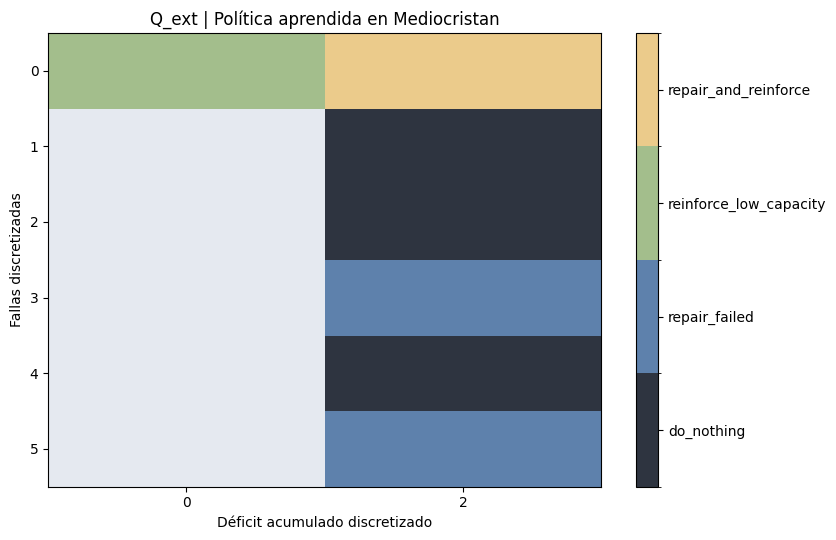


Resumen acciones Q_ext - Mediocristan
best_action
do_nothing                3
repair_failed             2
repair_and_reinforce      1
reinforce_low_capacity    1
Name: count, dtype: int64


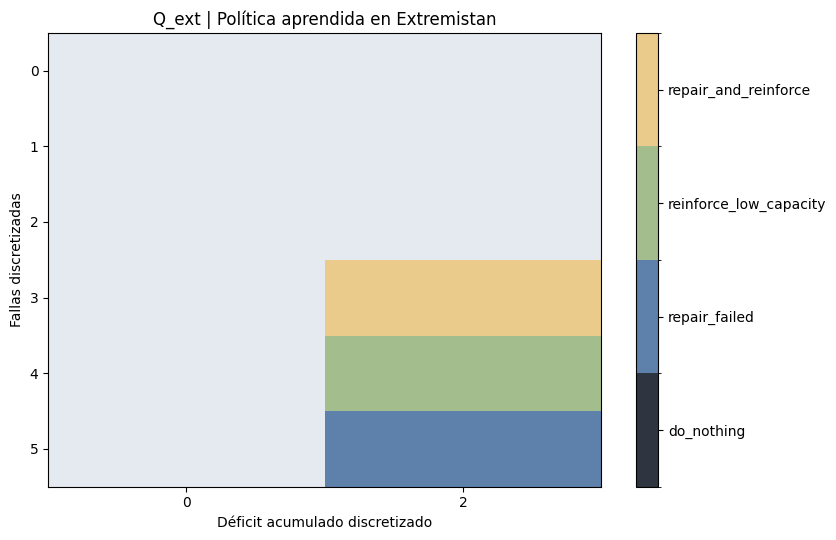


Resumen acciones Q_ext - Extremistan
best_action
repair_and_reinforce      1
reinforce_low_capacity    1
repair_failed             1
Name: count, dtype: int64


In [65]:
for Q_table, name in [
    (Q_mix, "Q_mix"),
    (Q_med, "Q_med"),
    (Q_ext, "Q_ext")
]:

    # Mediocristan
    plot_q_heatmap(
        Q=Q_table,
        policy_name=name,
        crisis_value=0,
        budget_bin=2,
        reinforced_bin=0
    )

    # Extremistan
    plot_q_heatmap(
        Q=Q_table,
        policy_name=name,
        crisis_value=1,
        budget_bin=2,
        reinforced_bin=0
    )

In [66]:
def empirical_var_cvar(values, alpha=0.95):
    """
    Calcula VaR y CVaR empíricos para una distribución de costos.
    """
    values = np.asarray(values, dtype=float)
    var_alpha = np.percentile(values, 100 * alpha)
    cvar_alpha = values[values >= var_alpha].mean()
    return var_alpha, cvar_alpha

In [67]:
summary_rows = []

for policy, df_p in eval_all.groupby("policy"):

    costs = df_p["total_cost"].values
    deficits = df_p["total_deficit"].values

    VaR95, CVaR95 = empirical_var_cvar(costs, alpha=0.95)

    summary_rows.append({
        "Política": policy,
        "Media costo": costs.mean(),
        "Std costo": costs.std(ddof=1),
        "VaR95": VaR95,
        "CVaR95": CVaR95,
        "Costo mínimo": costs.min(),
        "Costo máximo": costs.max(),
        "Déficit promedio": deficits.mean(),
        "Tasa de violación": (deficits > 1e-6).mean(),
        "Presupuesto final promedio": df_p["final_budget"].mean(),
        "Refuerzos finales promedio": df_p["final_reinforced"].mean()
    })

summary_qlearning = pd.DataFrame(summary_rows)

summary_qlearning

,Política,Media costo,Std costo,VaR95,CVaR95,Costo mínimo,Costo máximo,Déficit promedio,Tasa de violación,Presupuesto final promedio,Refuerzos finales promedio
0,Q_ext,2.807216e+07,5.982250e+06,3.446956e+07,3.447228e+07,1.812252e+07,3.447228e+07,53006.787004,1.0,847.5,6.6
1,Q_med,2.800859e+07,6.192271e+06,3.473349e+07,3.487492e+07,1.772980e+07,3.487492e+07,53149.068268,1.0,742.5,15.0
2,Q_mix,2.812400e+07,6.095812e+06,3.457825e+07,3.458315e+07,1.780167e+07,3.458315e+07,53361.370326,1.0,870.0,12.3


In [68]:
summary_qlearning_fmt = summary_qlearning.copy()

cols_format = [
    "Media costo",
    "Std costo",
    "VaR95",
    "CVaR95",
    "Costo mínimo",
    "Costo máximo",
    "Déficit promedio",
    "Presupuesto final promedio",
    "Refuerzos finales promedio"
]

for c in cols_format:
    summary_qlearning_fmt[c] = summary_qlearning_fmt[c].map(lambda x: f"{x:,.2f}")

summary_qlearning_fmt["Tasa de violación"] = (
    summary_qlearning["Tasa de violación"]
    .map(lambda x: f"{100*x:.1f}%")
)

summary_qlearning_fmt

,Política,Media costo,Std costo,VaR95,CVaR95,Costo mínimo,Costo máximo,Déficit promedio,Tasa de violación,Presupuesto final promedio,Refuerzos finales promedio
0,Q_ext,"28,072,164.04","5,982,249.55","34,469,560.05","34,472,283.95","18,122,519.48","34,472,283.95","53,006.79",100.0%,847.50,6.60
1,Q_med,"28,008,585.29","6,192,270.97","34,733,485.27","34,874,921.20","17,729,804.65","34,874,921.20","53,149.07",100.0%,742.50,15.00
2,Q_mix,"28,124,002.01","6,095,812.47","34,578,246.06","34,583,148.75","17,801,669.67","34,583,148.75","53,361.37",100.0%,870.00,12.30


In [69]:
def boxplot_qlearning(eval_all, metric="total_cost", ylabel="Costo total por episodio"):
    policies = ["Q_mix", "Q_med", "Q_ext"]
    data = [
        eval_all.loc[eval_all["policy"] == p, metric].dropna().values
        for p in policies
    ]

    fig, ax = plt.subplots(figsize=(10, 6))

    bp = ax.boxplot(
        data,
        labels=policies,
        patch_artist=True,
        showmeans=True,
        widths=0.55,
        medianprops={"linewidth": 2},
        meanprops={
            "marker": "D",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 7
        },
        boxprops={"linewidth": 1.5},
        whiskerprops={"linewidth": 1.3},
        capprops={"linewidth": 1.3},
        flierprops={
            "marker": "o",
            "markersize": 4,
            "alpha": 0.45
        }
    )

    colors = ["#8ecae6", "#90be6d", "#f4a261"]

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    for i, vals in enumerate(data, start=1):
        if len(vals) > 0:
            mean_val = np.mean(vals)
            med_val = np.median(vals)
            ax.text(
                i,
                mean_val,
                f" μ={mean_val:,.0f}",
                ha="left",
                va="center",
                fontsize=9
            )
            ax.text(
                i,
                med_val,
                f" med={med_val:,.0f}",
                ha="left",
                va="center",
                fontsize=9
            )

    ax.set_title("Comparación estadística de políticas Q-learning", fontsize=14, weight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Política")
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

C:\Users\sofia\AppData\Local\Temp\ipykernel_14160\307826212.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


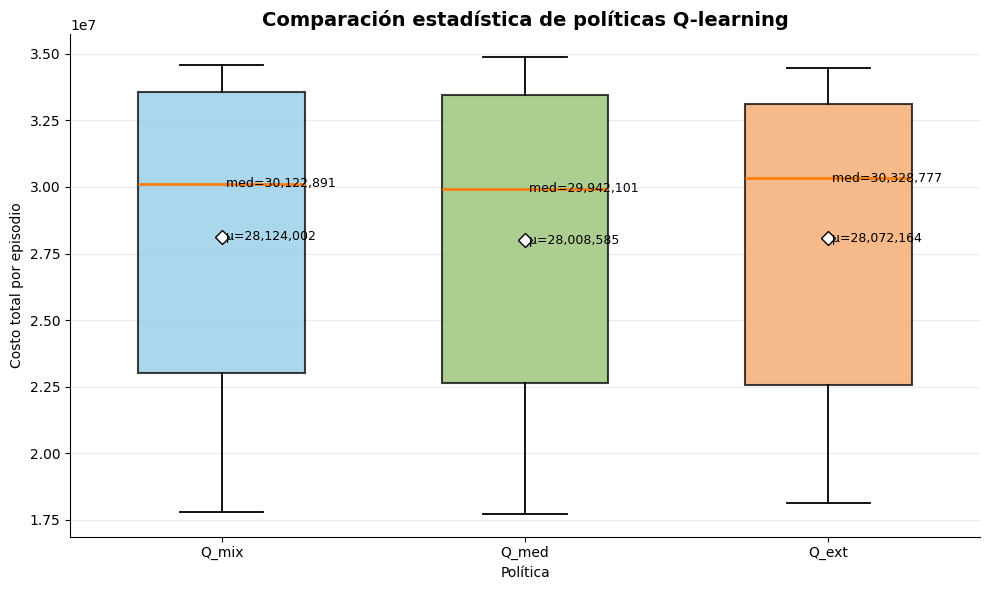

In [70]:
boxplot_qlearning(
    eval_all,
    metric="total_cost",
    ylabel="Costo total por episodio"
)

C:\Users\sofia\AppData\Local\Temp\ipykernel_14160\307826212.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


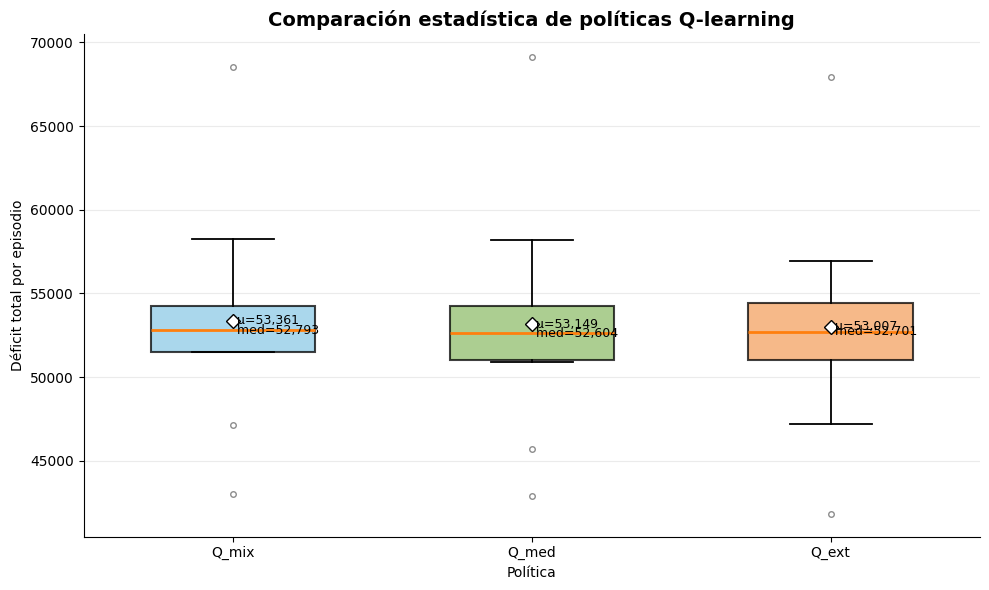

In [71]:
boxplot_qlearning(
    eval_all,
    metric="total_deficit",
    ylabel="Déficit total por episodio"
)

C:\Users\sofia\AppData\Local\Temp\ipykernel_14160\307826212.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


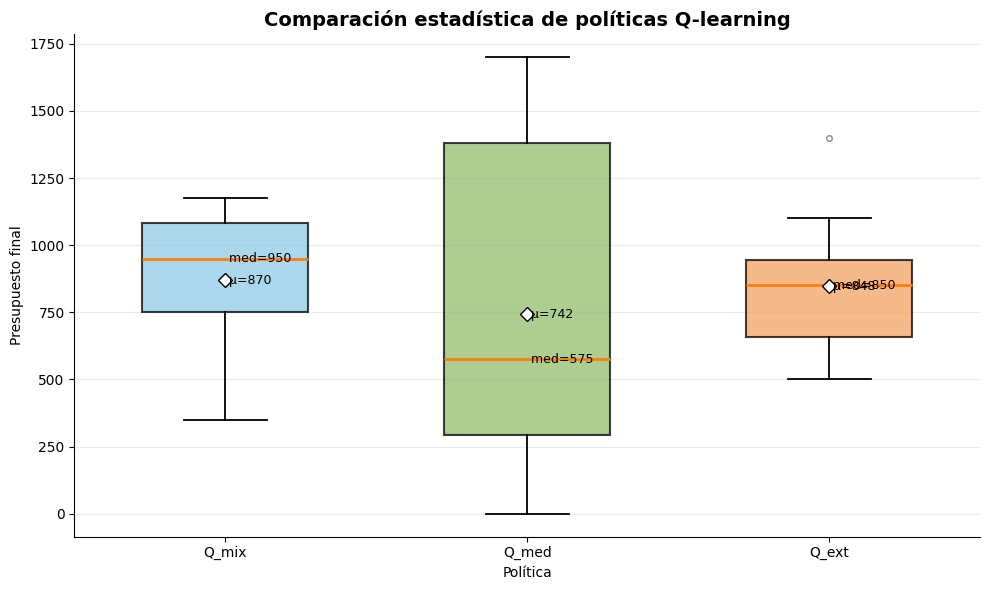

In [72]:
boxplot_qlearning(
    eval_all,
    metric="final_budget",
    ylabel="Presupuesto final"
)

In [73]:
# Criterio 1: menor media de costo
best_by_mean = summary_qlearning.loc[
    summary_qlearning["Media costo"].idxmin()
]

# Criterio 2: menor CVaR95
best_by_cvar = summary_qlearning.loc[
    summary_qlearning["CVaR95"].idxmin()
]

print("Mejor por costo promedio:")
print(best_by_mean)

print("\nMejor por CVaR95:")
print(best_by_cvar)

Mejor por costo promedio:
Política                                Q_med
Media costo                   28008585.289432
Std costo                      6192270.971867
VaR95                          34733485.27225
CVaR95                        34874921.199942
Costo mínimo                  17729804.653973
Costo máximo                  34874921.199942
Déficit promedio                 53149.068268
Tasa de violación                         1.0
Presupuesto final promedio              742.5
Refuerzos finales promedio               15.0
Name: 1, dtype: object

Mejor por CVaR95:
Política                                Q_ext
Media costo                   28072164.044134
Std costo                      5982249.550138
VaR95                         34469560.054575
CVaR95                        34472283.948105
Costo mínimo                  18122519.483832
Costo máximo                  34472283.948105
Déficit promedio                 53006.787004
Tasa de violación                         1.0
Presupuesto 

In [74]:
summary_rank = summary_qlearning.copy()

summary_rank["rank_media"] = summary_rank["Media costo"].rank()
summary_rank["rank_cvar"] = summary_rank["CVaR95"].rank()
summary_rank["rank_deficit"] = summary_rank["Déficit promedio"].rank()

summary_rank["score_total"] = (
    summary_rank["rank_media"]
    + summary_rank["rank_cvar"]
    + summary_rank["rank_deficit"]
)

best_policy_overall = summary_rank.loc[
    summary_rank["score_total"].idxmin()
]

best_policy_overall

Política                                Q_ext
Media costo                   28072164.044134
Std costo                      5982249.550138
VaR95                         34469560.054575
CVaR95                        34472283.948105
Costo mínimo                  18122519.483832
Costo máximo                  34472283.948105
Déficit promedio                 53006.787004
Tasa de violación                         1.0
Presupuesto final promedio              847.5
Refuerzos finales promedio                6.6
rank_media                                2.0
rank_cvar                                 1.0
rank_deficit                              1.0
score_total                               4.0
Name: 0, dtype: object

In [75]:
from collections import Counter
counter = Counter()

for (s, a), value in Q_ext.items():

    best_action = min(
        ACTION_NAMES,
        key=lambda x: Q_ext.get((s, x), np.inf)
    )

    counter[best_action] += 1

counter
freq_df = pd.DataFrame({
    "Acción": list(counter.keys()),
    "Frecuencia": list(counter.values())
})

freq_df["Porcentaje"] = (
    100
    * freq_df["Frecuencia"]
    / freq_df["Frecuencia"].sum()
)

freq_df.sort_values(
    "Frecuencia",
    ascending=False
)

,Acción,Frecuencia,Porcentaje
2,do_nothing,68,41.212121
3,repair_failed,52,31.515152
0,reinforce_low_capacity,24,14.545455
1,repair_and_reinforce,21,12.727273


### 3.3 DLA — Direct Lookahead Approximation

Esta sección integra `modelo_DLA.ipynb` dentro de `modelo.ipynb` usando el archivo `dla_highs.py`.

Se implementan dos variantes:

- **DLA determinístico:** usa un pronóstico puntual sobre horizonte rodante `H`.
- **DLA estocástico:** usa varios escenarios futuros sobre horizonte `H`.

In [76]:
import os
import sys
import subprocess
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar que Python busque módulos en la carpeta actual del notebook
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

# Instalar highspy solo si hace falta
try:
    import highspy
except ModuleNotFoundError:
    subprocess.run([sys.executable, "-m", "pip", "install", "highspy", "-q"], check=True)
    import highspy

# Importar tu archivo dla_highs.py
import dla_highs
importlib.reload(dla_highs)

from dla_highs import (
    solve_dla_deterministic_optimization,
    dla_deterministic_optimization_policy_fn,
    solve_dla_stochastic_optimization,
    dla_stochastic_optimization_policy_fn,
)

print("dla_highs.py importado correctamente")

dla_highs.py importado correctamente


In [77]:
# Forecast determinístico y conexión con dla_highs.py
def deterministic_forecast_W(
    t,
    dfD_dyn,
    dfU_dyn,
    dfc_dyn,
    dfG_dyn,
    df_info_dyn,
    forecast_mode="mean",
    forecast_path=0
):
    """
    Construye un pronóstico determinístico W_t.

    forecast_mode:
    - "path": usa un path específico.
    - "mean": usa el promedio de todos los paths disponibles para ese periodo.
    """

    t_max = int(df_info_dyn["t"].max())
    t = int(min(max(t, 1), t_max))

    if forecast_mode == "path":
        available_paths = sorted(df_info_dyn["path"].unique())
        if forecast_path not in available_paths:
            forecast_path = int(available_paths[0])

        return get_exogenous_info(
            path=int(forecast_path),
            t=t,
            dfD_dyn=dfD_dyn,
            dfU_dyn=dfU_dyn,
            dfc_dyn=dfc_dyn,
            dfG_dyn=dfG_dyn,
            df_info_dyn=df_info_dyn
        )

    # Pronóstico promedio por periodo
    D_t = (
        dfD_dyn[dfD_dyn["t"] == t]
        .groupby("node")["D_it"]
        .mean()
        .to_dict()
    )

    U_t = (
        dfU_dyn[dfU_dyn["t"] == t]
        .groupby("e_id")["U_et"]
        .mean()
        .to_dict()
    )

    failed_t = (
        dfU_dyn[dfU_dyn["t"] == t]
        .groupby("e_id")["failed"]
        .mean()
        .ge(0.5)
        .astype(int)
        .to_dict()
    )

    c_t = (
        dfc_dyn[dfc_dyn["t"] == t]
        .groupby("e_id")["c_et"]
        .mean()
        .to_dict()
    )

    G_t = (
        dfG_dyn[dfG_dyn["t"] == t]
        .groupby("node")["G_it"]
        .mean()
        .to_dict()
    )

    info_t = df_info_dyn[df_info_dyn["t"] == t]

    return {
        "D": D_t,
        "U": U_t,
        "failed": failed_t,
        "c": c_t,
        "G": G_t,
        "crisis": bool(info_t["crisis"].mean() >= 0.5),
        "dem_mult": float(info_t["dem_mult"].mean()),
        "cost_mult": float(info_t["cost_mult"].mean())
    }


def build_deterministic_W_list(state, W_current, params):
    """
    Construye la lista de información exógena que usa el DLA determinístico.

    La lista siempre empieza con W_current, porque esa es la información ya observada
    para tomar la decisión actual. Luego agrega pronósticos futuros hasta completar H.
    """

    H = int(params.get("H", 2))
    T = int(params.get("T", params["df_info_dyn"]["t"].max()))

    dfD_ = params["dfD_dyn"]
    dfU_ = params["dfU_dyn"]
    dfc_ = params["dfc_dyn"]
    dfG_ = params["dfG_dyn"]
    dfi_ = params["df_info_dyn"]

    forecast_mode = params.get("forecast_mode", "mean")
    forecast_path = params.get("forecast_path", 0)

    # En run_episode: state['t'] es el número de periodos ya ejecutados.
    # W_current corresponde a state['t'] + 1.
    current_t = int(state.get("t", 0)) + 1

    W_list = [W_current]

    # Agregar periodos futuros: current_t + 1, current_t + 2, ...
    for tau in range(current_t + 1, min(T, current_t + H - 1) + 1):
        W_tau = deterministic_forecast_W(
            t=tau,
            dfD_dyn=dfD_,
            dfU_dyn=dfU_,
            dfc_dyn=dfc_,
            dfG_dyn=dfG_,
            df_info_dyn=dfi_,
            forecast_mode=forecast_mode,
            forecast_path=forecast_path
        )
        W_list.append(W_tau)

    return W_list


# Pasar funciones del notebook al módulo dla_highs.py.
# Esto es necesario porque dla_highs.py las usa internamente.
dla_highs.build_deterministic_W_list = build_deterministic_W_list
dla_highs.get_exogenous_info = get_exogenous_info
dla_highs.build_action = build_action

In [78]:
# Probar DLA determinístico en un episodio

T_DLA_TEST = int(df_info_dyn["t"].max())
PATH_DLA_TEST = 0

H_e = {int(e): 50.0 for e in edges["e_id"]}

dla_det_params = {
    "H": 2,
    "T": T_DLA_TEST,
    "gamma": 0.95,
    "max_edges": 3,
    "delta_u": 0.8,
    "repair_cost": 25.0,
    "pi": 190.0,
    "time_limit": 10,

    "dfD_dyn": dfD_dyn,
    "dfU_dyn": dfU_dyn,
    "dfc_dyn": dfc_dyn,
    "dfG_dyn": dfG_dyn,
    "df_info_dyn": df_info_dyn,

    "forecast_mode": "mean",
    "forecast_path": PATH_DLA_TEST
}

episode_dla_det = run_episode(
    policy_fn=dla_deterministic_optimization_policy_fn,
    path=PATH_DLA_TEST,
    T=T_DLA_TEST,
    nodes=nodes,
    edges=edges,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    H_e=H_e,
    budget=2000.0,
    policy_params=dla_det_params
)

episode_dla_det.head(12)

,path,t,crisis,budget_remaining,period_cost,operating_cost,reinforcement_cost,repair_cost,deficit_cost,total_deficit,served_demand,total_flow,total_generation_dispatch,num_failed_edges,num_reinforced_edges,action_reinforce,action_repair,cumulative_cost,cumulative_deficit
0,0,1,False,1850.0,2.164331e+05,98314.598806,150.0,0.0,117968.522423,620.886960,2702.928161,8016.650110,7223.480905,4,3,"[58, 93, 94]",[],2.164331e+05,620.886960
1,0,2,False,1775.0,2.002319e+05,95762.165001,50.0,25.0,104394.759188,549.446101,2396.517693,6935.838497,7060.451530,5,4,[106],[148],4.166650e+05,1170.333061
2,0,3,False,1725.0,2.279402e+05,110231.717363,50.0,0.0,117658.456102,619.255032,2701.003135,8018.833422,7040.446997,8,5,[21],[],6.446052e+05,1789.588093
3,0,4,False,1500.0,2.671355e+05,120870.184898,150.0,75.0,146040.287954,768.633094,2888.136781,9138.387620,6469.703542,9,8,"[34, 48, 122]","[39, 76, 99]",9.117407e+05,2558.221188
4,0,5,False,1425.0,2.058445e+05,95170.483566,0.0,75.0,110599.009233,582.100049,2433.635653,7125.443571,7053.367206,7,8,[],"[31, 38, 124]",1.117585e+06,3140.321236
5,0,6,True,1350.0,1.105815e+06,143131.760533,50.0,25.0,962607.979866,5066.357789,3033.654125,6265.196626,6702.442415,41,9,[80],[142],2.223400e+06,8206.679025
6,0,7,False,1275.0,3.625304e+05,94514.305326,0.0,75.0,267941.074971,1410.216184,2279.397768,5648.992214,7146.446799,41,9,[],"[49, 106, 124]",2.585930e+06,9616.895209
7,0,8,False,1200.0,2.323772e+05,66009.653020,0.0,75.0,166292.522124,875.223801,1988.667738,4780.519591,6929.141585,41,9,[],"[30, 95, 159]",2.818307e+06,10492.119010
8,0,9,False,1125.0,2.086707e+05,71283.200170,0.0,75.0,137312.521005,722.697479,2117.788688,5669.845327,7308.415020,43,9,[],"[55, 70, 101]",3.026978e+06,11214.816489
9,0,10,False,1050.0,2.572297e+05,111319.082429,0.0,75.0,145835.574790,767.555657,2656.552159,8020.360968,7008.858703,41,9,[],"[94, 114, 133]",3.284208e+06,11982.372146


In [79]:
# Probar DLA estocástico en un episodio

dla_stoch_params = {
    "H": 2,
    "T": T_DLA_TEST,
    "num_scenarios": 3,
    "gamma": 0.95,
    "max_edges": 3,
    "delta_u": 0.8,
    "repair_cost": 25.0,
    "pi": 190.0,
    "time_limit": 10,

    "dfD_dyn": dfD_dyn,
    "dfU_dyn": dfU_dyn,
    "dfc_dyn": dfc_dyn,
    "dfG_dyn": dfG_dyn,
    "df_info_dyn": df_info_dyn
}

episode_dla_stoch = run_episode(
    policy_fn=dla_stochastic_optimization_policy_fn,
    path=PATH_DLA_TEST,
    T=T_DLA_TEST,
    nodes=nodes,
    edges=edges,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    H_e=H_e,
    budget=2000.0,
    policy_params=dla_stoch_params
)

episode_dla_stoch.head(12)

,path,t,crisis,budget_remaining,period_cost,operating_cost,reinforcement_cost,repair_cost,deficit_cost,total_deficit,served_demand,total_flow,total_generation_dispatch,num_failed_edges,num_reinforced_edges,action_reinforce,action_repair,cumulative_cost,cumulative_deficit
0,0,1,False,1850.0,2.164331e+05,98314.598806,150.0,0.0,117968.522423,620.886960,2702.928161,8016.650110,7223.480905,4,3,"[58, 93, 94]",[],2.164331e+05,620.886960
1,0,2,False,1775.0,2.002319e+05,95762.165001,50.0,25.0,104394.759188,549.446101,2396.517693,6935.838497,7060.451530,5,4,[106],[148],4.166650e+05,1170.333061
2,0,3,False,1725.0,2.279402e+05,110231.717363,50.0,0.0,117658.456102,619.255032,2701.003135,8018.833422,7040.446997,8,5,[21],[],6.446052e+05,1789.588093
3,0,4,False,1500.0,2.671355e+05,120870.184898,150.0,75.0,146040.287954,768.633094,2888.136781,9138.387620,6469.703542,9,8,"[34, 48, 122]","[39, 76, 99]",9.117407e+05,2558.221188
4,0,5,False,1425.0,2.058445e+05,95170.483566,0.0,75.0,110599.009233,582.100049,2433.635653,7125.443571,7053.367206,7,8,[],"[31, 38, 124]",1.117585e+06,3140.321236
5,0,6,True,1350.0,1.105815e+06,143131.760533,50.0,25.0,962607.979866,5066.357789,3033.654125,6265.196626,6702.442415,41,9,[80],[142],2.223400e+06,8206.679025
6,0,7,False,1275.0,3.644060e+05,77884.975722,0.0,75.0,286446.043765,1507.610757,2182.003195,4865.427547,7146.446799,41,9,[],"[30, 106, 124]",2.587806e+06,9714.289782
7,0,8,False,1200.0,2.323772e+05,66009.653020,0.0,75.0,166292.522124,875.223801,1988.667738,4780.519591,6929.141585,41,9,[],"[49, 95, 159]",2.820183e+06,10589.513582
8,0,9,False,1125.0,2.086707e+05,71283.200170,0.0,75.0,137312.521005,722.697479,2117.788688,5669.845327,7308.415020,43,9,[],"[55, 70, 101]",3.028854e+06,11312.211061
9,0,10,False,950.0,2.571117e+05,112364.142040,100.0,75.0,144572.547583,760.908145,2663.199670,8114.844364,7008.858703,41,11,"[59, 63]","[67, 94, 114]",3.285966e+06,12073.119207


,policy,total_cost,total_deficit,final_budget,final_reinforced
0,DLA determinístico,6.513444e+06,23391.941664,150.0,14
1,DLA estocástico,6.515201e+06,23482.688725,50.0,16


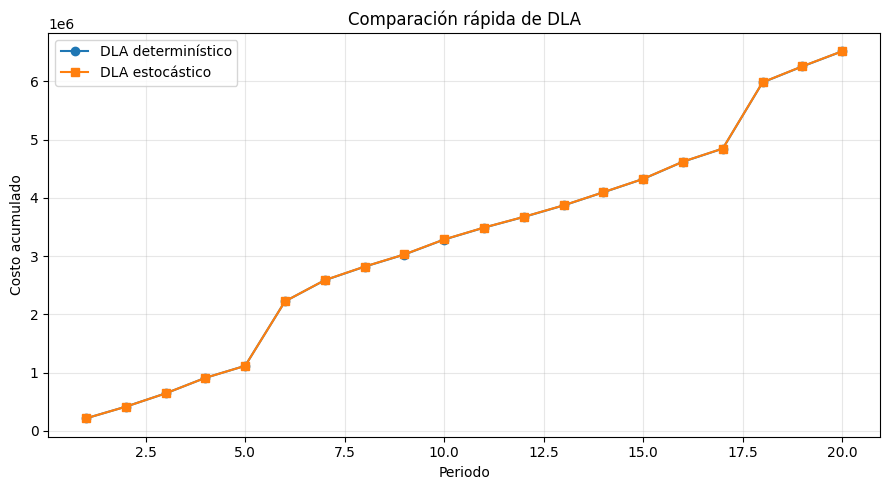

In [80]:
# Visualización rápida de DLA determinístico vs estocástico

dla_test_summary = pd.DataFrame([
    {
        "policy": "DLA determinístico",
        "total_cost": episode_dla_det["period_cost"].sum(),
        "total_deficit": episode_dla_det["total_deficit"].sum(),
        "final_budget": episode_dla_det["budget_remaining"].iloc[-1],
        "final_reinforced": episode_dla_det["num_reinforced_edges"].iloc[-1]
    },
    {
        "policy": "DLA estocástico",
        "total_cost": episode_dla_stoch["period_cost"].sum(),
        "total_deficit": episode_dla_stoch["total_deficit"].sum(),
        "final_budget": episode_dla_stoch["budget_remaining"].iloc[-1],
        "final_reinforced": episode_dla_stoch["num_reinforced_edges"].iloc[-1]
    }
])

display(dla_test_summary)

plt.figure(figsize=(9, 5))
plt.plot(episode_dla_det["t"], episode_dla_det["cumulative_cost"], marker="o", label="DLA determinístico")
plt.plot(episode_dla_stoch["t"], episode_dla_stoch["cumulative_cost"], marker="s", label="DLA estocástico")
plt.xlabel("Periodo")
plt.ylabel("Costo acumulado")
plt.title("Comparación rápida de DLA")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.4 Calibración y selección de políticas

El proceso tiene dos niveles:

1. **Selección intra-familia:** se prueban varias parametrizaciones dentro de cada familia.
2. **Torneo inter-familia:** se evalúa el mejor representante de cada familia con `N >= 50` episodios fuera de muestra.

Familias comparadas:

- PFA: regla de umbral.
- CFA: optimización proxy.
- VFA: Q-learning.
- DLA: rolling horizon determinístico/estocástico.

In [81]:
# Horizonte de cada episodio
T_34 = 12

# Episodios de calibración y evaluación
N_CALIB = 6
N_EVAL = 50
N_TOTAL = N_CALIB + N_EVAL

SEED_34 = 4040
BUDGET_34 = 2000.0

# Si PROJECT2_ARCS no existe por alguna razón, se crea una lista de respaldo
if "PROJECT2_ARCS" not in globals():
    PROJECT2_ARCS = edges["e_id"].astype(int).head(10).tolist()

H_e = {int(e): 50.0 for e in edges["e_id"]}

# Generar un nuevo ambiente para calibrar y evaluar con semillas distintas
# a las usadas antes en el notebook.
dfD_34, dfU_34, dfc_34, dfG_34, dfi_34 = generate_dynamic_scenarios(
    nodes=nodes,
    edges=edges,
    T=T_34,
    n_paths=N_TOTAL,
    seed=SEED_34,
    p_crisis=0.15,
    dem_sigma=0.20,
    cost_sigma=0.08,
    crisis_dem_mult=2.5,
    crisis_cost_mult=2.0,
    p_outage=0.03,
    crisis_p_outage=0.25,
    cap_drop=0.65
)

calib_paths = list(range(N_CALIB))
eval_paths = list(range(N_CALIB, N_TOTAL))

dfi_calib = dfi_34[dfi_34["path"].isin(calib_paths)].copy()

print("Paths de calibración:", len(calib_paths))
print("Paths de evaluación final:", len(eval_paths))
print("Cumple N >= 50:", len(eval_paths) >= 50)

Paths de calibración: 6
Paths de evaluación final: 50
Cumple N >= 50: True


In [82]:
# Funciones auxiliares para calibración y torneo
def empirical_cvar(values, alpha=0.90):
    """
    CVaR empírico: promedio del peor (1-alpha)% de los costos.
    """
    values = np.asarray(values, dtype=float)
    var_alpha = np.percentile(values, 100 * alpha)
    tail = values[values >= var_alpha]

    if len(tail) == 0:
        return float(var_alpha)

    return float(tail.mean())


def evaluate_policy_on_paths_34(
    policy_fn,
    policy_name,
    paths,
    T,
    nodes,
    edges,
    dfD_dyn,
    dfU_dyn,
    dfc_dyn,
    dfG_dyn,
    df_info_dyn,
    H_e,
    budget=2000.0,
    policy_params=None
):
    """
    Evalúa una política en varios episodios/paths.
    Retorna una fila por episodio.
    """

    if policy_params is None:
        policy_params = {}

    rows = []

    for path in paths:
        ep = run_episode(
            policy_fn=policy_fn,
            path=int(path),
            T=T,
            nodes=nodes,
            edges=edges,
            dfD_dyn=dfD_dyn,
            dfU_dyn=dfU_dyn,
            dfc_dyn=dfc_dyn,
            dfG_dyn=dfG_dyn,
            df_info_dyn=df_info_dyn,
            H_e=H_e,
            budget=budget,
            policy_params=policy_params
        )

        rows.append({
            "policy": policy_name,
            "path": int(path),
            "total_cost": ep["period_cost"].sum(),
            "total_deficit": ep["total_deficit"].sum(),
            "final_budget": ep["budget_remaining"].iloc[-1],
            "max_failed_edges": ep["num_failed_edges"].max(),
            "final_reinforced": ep["num_reinforced_edges"].iloc[-1],
            "crisis_share": ep["crisis"].mean()
        })

    return pd.DataFrame(rows)


def summarize_policy_results(df, group_col="policy"):
    """
    Resume desempeño por política.
    """
    return (
        df.groupby(group_col)
        .agg(
            costo_promedio=("total_cost", "mean"),
            costo_std=("total_cost", "std"),
            costo_min=("total_cost", "min"),
            costo_max=("total_cost", "max"),
            CVaR90=("total_cost", lambda x: empirical_cvar(x, alpha=0.90)),
            deficit_promedio=("total_deficit", "mean"),
            tasa_violacion=("total_deficit", lambda x: (x > 1e-6).mean()),
            presupuesto_final_promedio=("final_budget", "mean"),
            refuerzos_finales_promedio=("final_reinforced", "mean")
        )
        .reset_index()
        .sort_values("costo_promedio")
    )


def make_q_policy_34(Q_table):
    """
    Convierte una tabla Q en una policy_fn compatible con run_episode.
    """
    def policy_fn(state, W, nodes, edges, H_e, params=None):
        return q_learning_policy_fn(
            state=state,
            W=W,
            nodes=nodes,
            edges=edges,
            H_e=H_e,
            params={"Q": Q_table}
        )
    return policy_fn

In [83]:
# Q-learning para calibración VFA

def q_learning_train_quiet(
    nodes,
    edges,
    H_e,
    dfD_dyn,
    dfU_dyn,
    dfc_dyn,
    dfG_dyn,
    df_info_dyn,
    T=12,
    n_episodes=150,
    alpha=0.10,
    gamma=0.95,
    epsilon=0.20,
    budget=2000.0,
    seed=123
):
    rng = np.random.default_rng(seed)
    Q = {}
    episode_returns = []
    available_paths = df_info_dyn["path"].unique()

    for ep in range(n_episodes):
        path = int(rng.choice(available_paths))
        state = initialize_state(nodes=nodes, edges=edges, budget=budget)
        total_return = 0.0

        for t in range(1, T + 1):
            W = get_exogenous_info(
                path=path,
                t=t,
                dfD_dyn=dfD_dyn,
                dfU_dyn=dfU_dyn,
                dfc_dyn=dfc_dyn,
                dfG_dyn=dfG_dyn,
                df_info_dyn=df_info_dyn
            )

            s = discretize_state(state)

            if rng.random() < epsilon:
                a_name = rng.choice(ACTION_NAMES)
            else:
                values = [Q.get((s, a), 0.0) for a in ACTION_NAMES]
                a_name = ACTION_NAMES[int(np.argmin(values))]

            action = build_action(
                action_name=a_name,
                state=state,
                W=W,
                nodes=nodes,
                edges=edges,
                H_e=H_e
            )

            next_state, info = transition(
                state=state,
                action=action,
                W=W,
                nodes=nodes,
                edges=edges,
                H_e=H_e
            )

            cost = info["cost_breakdown"]["total_cost"]
            total_return += cost
            s_next = discretize_state(next_state)

            best_next = min(Q.get((s_next, a_next), 0.0) for a_next in ACTION_NAMES)
            old_q = Q.get((s, a_name), 0.0)

            Q[(s, a_name)] = old_q + alpha * (cost + gamma * best_next - old_q)
            state = next_state

        episode_returns.append(total_return)

    return Q, episode_returns

In [84]:
# Nivel 1: calibración intra-familia CFA

cfa_grid = [
    {
        "pi_proxy": 160.0,
        "repair_cost": 25.0,
        "conservatism": 0.25,
        "max_repair_per_period": 2,
        "max_reinforce_per_period": 2,
        "flow_factor": 0.25,
        "candidate_edges": PROJECT2_ARCS
    },
    {
        "pi_proxy": 190.0,
        "repair_cost": 25.0,
        "conservatism": 0.50,
        "max_repair_per_period": 2,
        "max_reinforce_per_period": 2,
        "flow_factor": 0.25,
        "candidate_edges": PROJECT2_ARCS
    },
    {
        "pi_proxy": 220.0,
        "repair_cost": 25.0,
        "conservatism": 0.75,
        "max_repair_per_period": 3,
        "max_reinforce_per_period": 2,
        "flow_factor": 0.30,
        "candidate_edges": PROJECT2_ARCS
    }
]

cfa_calib_rows = []

for k, params in enumerate(cfa_grid):
    df_eval = evaluate_policy_on_paths_34(
        policy_fn=baseline_CFA_proxy_policy,
        policy_name=f"CFA_{k}",
        paths=calib_paths,
        T=T_34,
        nodes=nodes,
        edges=edges,
        dfD_dyn=dfD_34,
        dfU_dyn=dfU_34,
        dfc_dyn=dfc_34,
        dfG_dyn=dfG_34,
        df_info_dyn=dfi_34,
        H_e=H_e,
        budget=BUDGET_34,
        policy_params=params
    )

    cfa_calib_rows.append({
        "family": "CFA",
        "variant": f"CFA_{k}",
        "mean_cost": df_eval["total_cost"].mean(),
        "mean_deficit": df_eval["total_deficit"].mean(),
        "params": params
    })

cfa_calibration = pd.DataFrame(cfa_calib_rows)
best_cfa_row = cfa_calibration.sort_values("mean_cost").iloc[0]
best_cfa_params = best_cfa_row["params"]

cfa_calibration

,family,variant,mean_cost,mean_deficit,params
0,CFA,CFA_0,8.622881e+06,43928.773670,"{'pi_proxy': 160.0, 'repair_cost': 25.0, 'cons..."
1,CFA,CFA_1,8.622881e+06,43928.773670,"{'pi_proxy': 190.0, 'repair_cost': 25.0, 'cons..."
2,CFA,CFA_2,8.608098e+06,43631.710724,"{'pi_proxy': 220.0, 'repair_cost': 25.0, 'cons..."


In [85]:
# Nivel 1: calibración intra-familia VFA / Q-learning

q_grid = [
    {
        "alpha": 0.05,
        "gamma": 0.90,
        "epsilon": 0.30,
        "n_episodes": 150,
        "seed": 2026
    },
    {
        "alpha": 0.08,
        "gamma": 0.95,
        "epsilon": 0.25,
        "n_episodes": 150,
        "seed": 2027
    },
    {
        "alpha": 0.10,
        "gamma": 0.95,
        "epsilon": 0.15,
        "n_episodes": 150,
        "seed": 2028
    }
]

q_calib_rows = []
q_objects = {}

for k, cfg in enumerate(q_grid):
    print(f"Entrenando Q_{k}...")

    Q_tmp, returns_tmp = q_learning_train_quiet(
        nodes=nodes,
        edges=edges,
        H_e=H_e,
        dfD_dyn=dfD_34,
        dfU_dyn=dfU_34,
        dfc_dyn=dfc_34,
        dfG_dyn=dfG_34,
        df_info_dyn=dfi_calib,
        T=T_34,
        n_episodes=cfg["n_episodes"],
        alpha=cfg["alpha"],
        gamma=cfg["gamma"],
        epsilon=cfg["epsilon"],
        budget=BUDGET_34,
        seed=cfg["seed"]
    )

    q_policy = make_q_policy_34(Q_tmp)

    df_eval = evaluate_policy_on_paths_34(
        policy_fn=q_policy,
        policy_name=f"Q_{k}",
        paths=calib_paths,
        T=T_34,
        nodes=nodes,
        edges=edges,
        dfD_dyn=dfD_34,
        dfU_dyn=dfU_34,
        dfc_dyn=dfc_34,
        dfG_dyn=dfG_34,
        df_info_dyn=dfi_34,
        H_e=H_e,
        budget=BUDGET_34,
        policy_params={}
    )

    q_objects[f"Q_{k}"] = {
        "Q": Q_tmp,
        "returns": returns_tmp,
        "params": cfg,
        "policy_fn": q_policy
    }

    q_calib_rows.append({
        "family": "VFA",
        "variant": f"Q_{k}",
        "mean_cost": df_eval["total_cost"].mean(),
        "mean_deficit": df_eval["total_deficit"].mean(),
        "params": cfg
    })

q_calibration = pd.DataFrame(q_calib_rows)
best_q_row = q_calibration.sort_values("mean_cost").iloc[0]
best_q_name = best_q_row["variant"]
best_Q = q_objects[best_q_name]["Q"]
best_q_policy_fn = q_objects[best_q_name]["policy_fn"]

q_calibration

Entrenando Q_0...
Entrenando Q_1...
Entrenando Q_2...


,family,variant,mean_cost,mean_deficit,params
0,VFA,Q_0,1.806969e+07,38421.373482,"{'alpha': 0.05, 'gamma': 0.9, 'epsilon': 0.3, ..."
1,VFA,Q_1,1.807528e+07,38278.642131,"{'alpha': 0.08, 'gamma': 0.95, 'epsilon': 0.25..."
2,VFA,Q_2,1.802887e+07,38216.674480,"{'alpha': 0.1, 'gamma': 0.95, 'epsilon': 0.15,..."


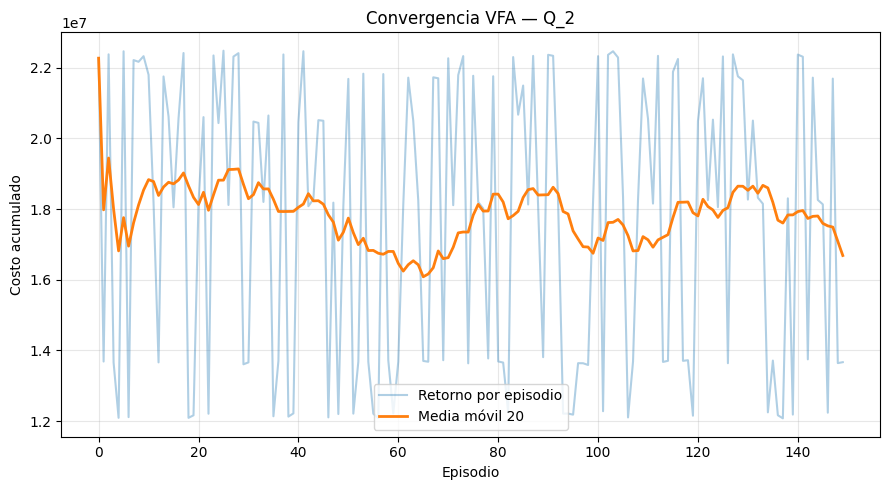

In [86]:
# Curva de convergencia del mejor VF

best_returns = q_objects[best_q_name]["returns"]

plt.figure(figsize=(9, 5))
plt.plot(best_returns, alpha=0.35, label="Retorno por episodio")

window = 20
plt.plot(
    pd.Series(best_returns).rolling(window, min_periods=1).mean(),
    linewidth=2,
    label=f"Media móvil {window}"
)

plt.xlabel("Episodio")
plt.ylabel("Costo acumulado")
plt.title(f"Convergencia VFA — {best_q_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [87]:
# Nivel 1: calibración intra-familia DLA

# Para evitar tiempos excesivos, se calibra un grid compacto.
# El torneo final sí usa N_EVAL = 50 episodios.
dla_grid = [
    {"variant_type": "Determinístico", "H": 1, "num_scenarios": None},
    {"variant_type": "Determinístico", "H": 2, "num_scenarios": None},
    {"variant_type": "Estocástico", "H": 1, "num_scenarios": 3},
    {"variant_type": "Estocástico", "H": 2, "num_scenarios": 3},
]

dla_calib_rows = []

for k, cfg in enumerate(dla_grid):
    print(f"Calibrando DLA {cfg['variant_type']} | H={cfg['H']}")

    base_params = {
        "H": cfg["H"],
        "T": T_34,
        "gamma": 0.95,
        "max_edges": 3,
        "delta_u": 0.8,
        "repair_cost": 25.0,
        "pi": 190.0,
        "time_limit": 5,

        "dfD_dyn": dfD_34,
        "dfU_dyn": dfU_34,
        "dfc_dyn": dfc_34,
        "dfG_dyn": dfG_34,
        "df_info_dyn": dfi_34,

        "forecast_mode": "mean"
    }

    if cfg["variant_type"] == "Estocástico":
        base_params["num_scenarios"] = cfg["num_scenarios"]
        policy_fn = dla_stochastic_optimization_policy_fn
    else:
        policy_fn = dla_deterministic_optimization_policy_fn

    df_eval = evaluate_policy_on_paths_34(
        policy_fn=policy_fn,
        policy_name=f"DLA_{cfg['variant_type']}_H{cfg['H']}",
        paths=calib_paths,
        T=T_34,
        nodes=nodes,
        edges=edges,
        dfD_dyn=dfD_34,
        dfU_dyn=dfU_34,
        dfc_dyn=dfc_34,
        dfG_dyn=dfG_34,
        df_info_dyn=dfi_34,
        H_e=H_e,
        budget=BUDGET_34,
        policy_params=base_params
    )

    dla_calib_rows.append({
        "family": "DLA",
        "variant": f"DLA_{cfg['variant_type']}_H{cfg['H']}",
        "variant_type": cfg["variant_type"],
        "H": cfg["H"],
        "mean_cost": df_eval["total_cost"].mean(),
        "mean_deficit": df_eval["total_deficit"].mean(),
        "params": base_params
    })

dla_calibration = pd.DataFrame(dla_calib_rows)
best_dla_row = dla_calibration.sort_values("mean_cost").iloc[0]
best_dla_params = best_dla_row["params"]

if best_dla_row["variant_type"] == "Estocástico":
    best_dla_policy_fn = dla_stochastic_optimization_policy_fn
else:
    best_dla_policy_fn = dla_deterministic_optimization_policy_fn

dla_calibration

Calibrando DLA Determinístico | H=1
Calibrando DLA Determinístico | H=2
Calibrando DLA Estocástico | H=1
Calibrando DLA Estocástico | H=2


StopIteration: 

StopIteration: 

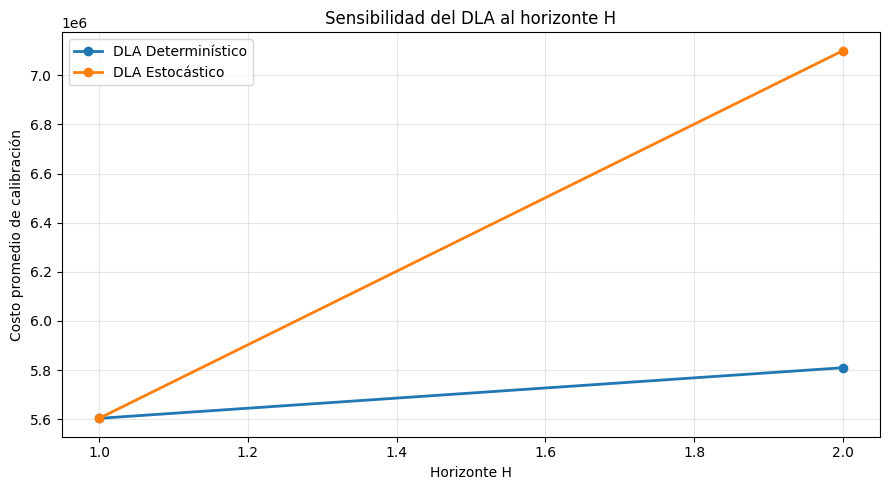

In [88]:
# Visualización: sensibilidad del DLA al horizonte H

plt.figure(figsize=(9, 5))

for variant_type in dla_calibration["variant_type"].unique():
    subset = dla_calibration[dla_calibration["variant_type"] == variant_type].sort_values("H")

    plt.plot(
        subset["H"],
        subset["mean_cost"],
        marker="o",
        linewidth=2,
        label=f"DLA {variant_type}"
    )

plt.xlabel("Horizonte H")
plt.ylabel("Costo promedio de calibración")
plt.title("Sensibilidad del DLA al horizonte H")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [92]:
# Nivel 2: torneo inter-familia con N >= 50 episodios

final_policy_specs = [
    {
        "policy": "CFA_best",
        "family": "CFA",
        "policy_fn": baseline_CFA_proxy_policy,
        "params": best_cfa_params
    },
    {
        "policy": f"VFA_{best_q_name}",
        "family": "VFA",
        "policy_fn": best_q_policy_fn,
        "params": {}
    },
    {
        "policy": best_dla_row["variant"],
        "family": "DLA",
        "policy_fn": best_dla_policy_fn,
        "params": best_dla_params
    }
]

tournament_parts = []

for spec in final_policy_specs:
    print(f"Evaluando torneo final: {spec['policy']}")

    params = spec["params"].copy()

    # Asegurar que DLA use los datos correctos del torneo
    if spec["family"] == "DLA":
        params.update({
            "T": T_34,
            "dfD_dyn": dfD_34,
            "dfU_dyn": dfU_34,
            "dfc_dyn": dfc_34,
            "dfG_dyn": dfG_34,
            "df_info_dyn": dfi_34
        })

    df_eval = evaluate_policy_on_paths_34(
        policy_fn=spec["policy_fn"],
        policy_name=spec["policy"],
        paths=eval_paths,
        T=T_34,
        nodes=nodes,
        edges=edges,
        dfD_dyn=dfD_34,
        dfU_dyn=dfU_34,
        dfc_dyn=dfc_34,
        dfG_dyn=dfG_34,
        df_info_dyn=dfi_34,
        H_e=H_e,
        budget=BUDGET_34,
        policy_params=params
    )

    df_eval["family"] = spec["family"]
    tournament_parts.append(df_eval)

tournament_df = pd.concat(tournament_parts, ignore_index=True)

print("Episodios evaluados por política:")
display(tournament_df.groupby("policy")["path"].count().reset_index(name="n_episodios"))

tournament_df.head()

Evaluando torneo final: CFA_best
Evaluando torneo final: VFA_Q_2
Evaluando torneo final: DLA_Determinístico_H1
Episodios evaluados por política:


,policy,n_episodios
0,CFA_best,50
1,DLA_Determinístico_H1,50
2,VFA_Q_2,50


,policy,path,total_cost,total_deficit,final_budget,max_failed_edges,final_reinforced,crisis_share,family
0,CFA_best,6,7.531356e+06,37734.204359,2000.0,79,0,0.083333,CFA
1,CFA_best,7,9.196473e+06,47146.050773,1925.0,134,0,0.250000,CFA
2,CFA_best,8,9.420287e+06,47918.770369,1850.0,117,0,0.250000,CFA
3,CFA_best,9,1.051197e+07,54160.754171,2000.0,132,0,0.333333,CFA
4,CFA_best,10,5.489538e+06,26911.759648,2000.0,54,0,0.000000,CFA


In [93]:
# Tabla final del torneo

summary_tournament = summarize_policy_results(tournament_df, group_col="policy")

summary_tournament_fmt = summary_tournament.copy()

cols_to_format = [
    "costo_promedio",
    "costo_std",
    "costo_min",
    "costo_max",
    "CVaR90",
    "deficit_promedio",
    "presupuesto_final_promedio",
    "refuerzos_finales_promedio"
]

for col in cols_to_format:
    summary_tournament_fmt[col] = summary_tournament_fmt[col].map(lambda x: f"{x:,.2f}")

summary_tournament_fmt["tasa_violacion"] = (
    summary_tournament["tasa_violacion"].map(lambda x: f"{100*x:.1f}%")
)

summary_tournament_fmt

,policy,costo_promedio,costo_std,costo_min,costo_max,CVaR90,deficit_promedio,tasa_violacion,presupuesto_final_promedio,refuerzos_finales_promedio
1,DLA_Determinístico_H1,"5,005,274.79","1,411,291.52","2,666,135.76","8,563,247.49","7,773,326.35","20,958.41",100.0%,754.00,10.54
0,CFA_best,"7,997,958.70","1,419,457.68","5,489,538.45","11,906,028.67","10,810,117.38","40,296.92",100.0%,"1,961.00",0.00
2,VFA_Q_2,"18,918,655.64","3,389,072.92","9,762,695.58","27,275,111.45","23,399,079.36","35,204.41",100.0%,557.50,23.10


C:\Users\sofia\AppData\Local\Temp\ipykernel_14160\1407454294.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=policies_order, showmeans=True)


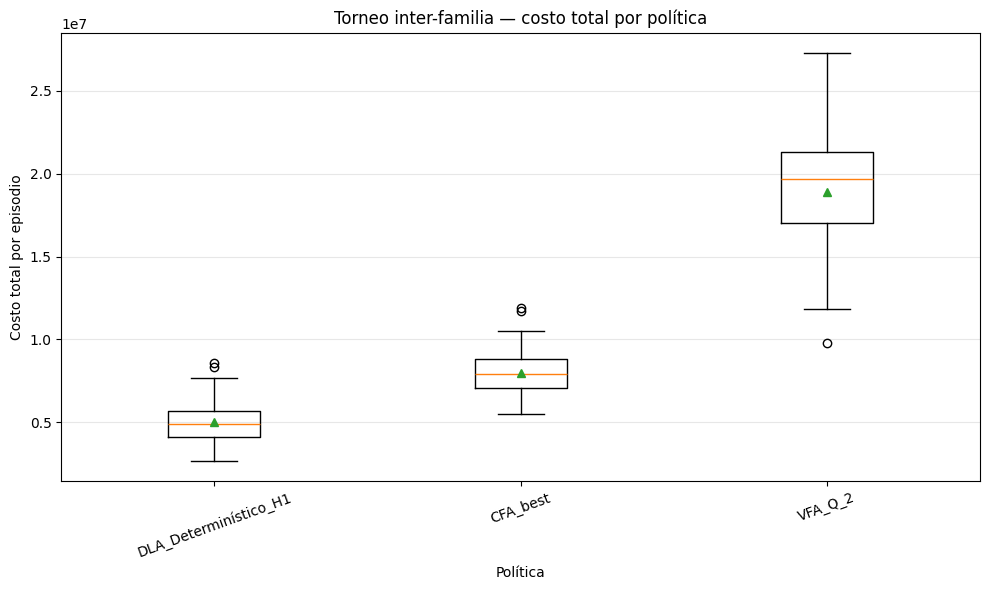

In [94]:
# Boxplot de costo total por política

policies_order = summary_tournament["policy"].tolist()

data = [
    tournament_df.loc[tournament_df["policy"] == p, "total_cost"].values
    for p in policies_order
]

plt.figure(figsize=(10, 6))
plt.boxplot(data, labels=policies_order, showmeans=True)
plt.ylabel("Costo total por episodio")
plt.xlabel("Política")
plt.title("Torneo inter-familia — costo total por política")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

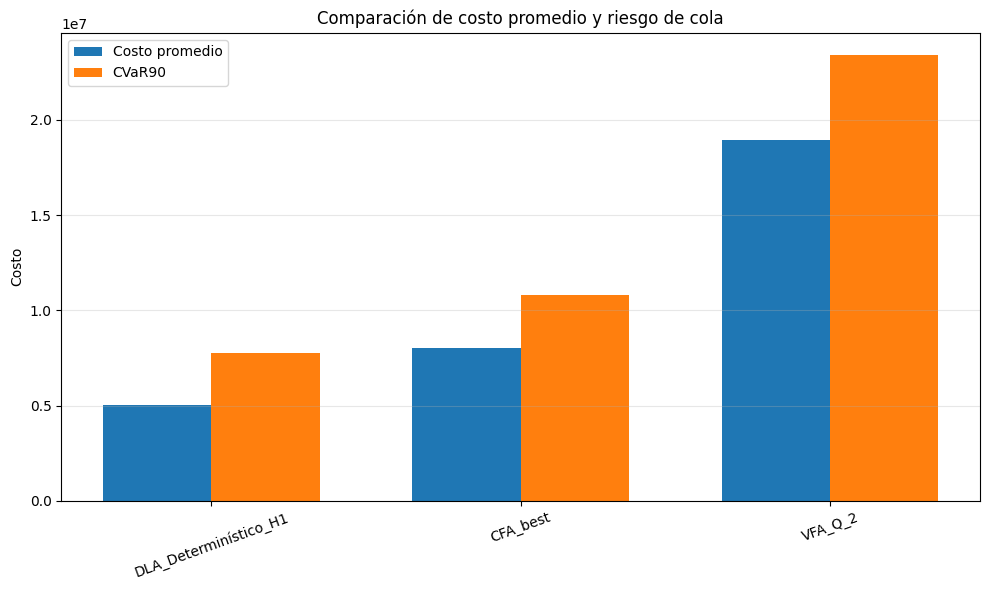

In [95]:
# Comparación costo promedio vs CVaR90

x = np.arange(len(summary_tournament))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    summary_tournament["costo_promedio"],
    width,
    label="Costo promedio"
)

plt.bar(
    x + width / 2,
    summary_tournament["CVaR90"],
    width,
    label="CVaR90"
)

plt.xticks(x, summary_tournament["policy"], rotation=20)
plt.ylabel("Costo")
plt.title("Comparación de costo promedio y riesgo de cola")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [96]:
# Selección final recomendada

ranking = summary_tournament.copy()

ranking["rank_mean"] = ranking["costo_promedio"].rank(method="min")
ranking["rank_cvar"] = ranking["CVaR90"].rank(method="min")
ranking["rank_deficit"] = ranking["deficit_promedio"].rank(method="min")

ranking["score_total"] = (
    ranking["rank_mean"]
    + ranking["rank_cvar"]
    + ranking["rank_deficit"]
)

best_policy_final = ranking.sort_values("score_total").iloc[0]

print("Política recomendada según ranking combinado:")
display(best_policy_final)

ranking.sort_values("score_total")

Política recomendada según ranking combinado:


policy                        DLA_Determinístico_H1
costo_promedio                       5005274.788054
costo_std                            1411291.524997
costo_min                            2666135.763475
costo_max                             8563247.48633
CVaR90                               7773326.347521
deficit_promedio                       20958.409966
tasa_violacion                                  1.0
presupuesto_final_promedio                    754.0
refuerzos_finales_promedio                    10.54
rank_mean                                       1.0
rank_cvar                                       1.0
rank_deficit                                    1.0
score_total                                     3.0
Name: 1, dtype: object

,policy,costo_promedio,costo_std,costo_min,costo_max,CVaR90,deficit_promedio,tasa_violacion,presupuesto_final_promedio,refuerzos_finales_promedio,rank_mean,rank_cvar,rank_deficit,score_total
1,DLA_Determinístico_H1,5.005275e+06,1.411292e+06,2.666136e+06,8.563247e+06,7.773326e+06,20958.409966,1.0,754.0,10.54,1.0,1.0,1.0,3.0
0,CFA_best,7.997959e+06,1.419458e+06,5.489538e+06,1.190603e+07,1.081012e+07,40296.922924,1.0,1961.0,0.00,2.0,2.0,3.0,7.0
2,VFA_Q_2,1.891866e+07,3.389073e+06,9.762696e+06,2.727511e+07,2.339908e+07,35204.405186,1.0,557.5,23.10,3.0,3.0,2.0,8.0
